In [ ]:
# ================================================================
# PI-MRONJ full analysis — R (Google Colab)
# Auto-install + auto-load version
# ================================================================

# 1. apt-get based packages (install fast on Colab)
apt_pkgs <- c(
  "r-cran-readxl", "r-cran-dplyr", "r-cran-tidyr", "r-cran-ggplot2",
  "r-cran-survival", "r-cran-proc", "r-cran-rms", "r-cran-scales",
  "r-cran-caret", "r-cran-writexl", "r-cran-vgam", "r-cran-e1071",
  "r-cran-xgboost", "r-cran-car"
)

system("apt-get update")
system(paste("apt-get install -y", paste(apt_pkgs, collapse = " ")))

# 2. Packages that must be installed from CRAN
cran_pkgs <- c(
  "geepack", "survminer", "glmnet", "gridExtra", "cowplot", "tableone",
  "forestplot", "ggrepel", "viridis", "ggcorrplot", "dcurves",
  "corrplot", "RColorBrewer", "ResourceSelection", "randomForest",
  "patchwork", "svglite", "ggbreak"
)

# 3. Install only the packages not already installed
to_install <- cran_pkgs[!(cran_pkgs %in% installed.packages()[, "Package"])]

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cran.rstudio.com")
}

# 4. Load all packages
all_pkgs <- c(
  "readxl", "dplyr", "tidyr", "ggplot2", "geepack", "survival",
  "survminer", "glmnet", "pROC", "rms", "scales", "gridExtra",
  "cowplot", "tableone", "ggrepel", "viridis", "writexl", "caret",
  "e1071", "xgboost", "car", "ggcorrplot", "dcurves", "corrplot",
  "RColorBrewer", "ResourceSelection", "randomForest", "patchwork",
  "svglite", "ggbreak"
)

suppressPackageStartupMessages(
  lapply(all_pkgs, library, character.only = TRUE)
)

cat("✅ All required packages installed and loaded!\n")

# ── Paths & theme setup ───────────────────────────────────
DATA_PATH <- "/content/PI_MRONJ_v4.xlsx"
SAVE_DIR  <- "/content/Results_R"
dir.create(SAVE_DIR, showWarnings = FALSE, recursive = TRUE)

#theme_mronj <- theme_bw(base_size = 12) +
#  theme(plot.title    = element_text(face = "bold", hjust = 0.5),
#        plot.subtitle = element_text(hjust = 0.5, color = "gray40"),
#        legend.position = "bottom",
#        strip.background = element_rect(fill = "gray95"))

cat(sprintf("🚀 Setup complete! (save path: %s)\n", SAVE_DIR))


In [77]:
# ==============================================================================
# [CELL 2] Data preparation — df_tp (timepoint) + df_imp (implant) + sensitivity
#
#   df_tp  : for GEE
#   df_imp : for Cox / LOGO-CV
#
#   Usage:
#     1) change only the SENS_CUTOFF_MONTHS value
#     2) re-run this CELL 2 only
#
#   Downstream-compatible variables:
#     raw, df_tp, df_imp
#     clin_cols, radio_base, radio_wav, radio_all
#     tp_radio_raw, tp_radio_change, tp_radio_delta, tp_radio_slope
#     imp_radio_first, imp_radio_net, imp_radio_trend
# ==============================================================================

SENS_CUTOFF_MONTHS <- 0 # 0, 3, 6, 9 ...

build_raw_base <- function(data_path, sheet = "Coding") {
  raw0 <- read_excel(data_path, sheet = sheet)

  clin_cols0  <- c(
    "Insertion_Depth_mm", "Insertion_Angle_deviation",
    "Calculated_C_I_Ratio", "Crown_Height_mm",
    "Is_Single_Prosthesis", "Has_Cantilever",
    "Jaw_Code", "Region_Code", "Opposing_Teeth_Code"
  )

  radio_base0 <- names(raw0)[grepl("^(FO_|GLCM_|GLRLM_|GLSZM_|NGTDM_)", names(raw0))]
  radio_wav0  <- names(raw0)[grepl("^Wav_", names(raw0))]
  radio_all0  <- c(radio_base0, radio_wav0)

  num_cols0 <- c("Days_Since_Surgery", clin_cols0, radio_all0)

  raw0 <- raw0 %>%
    mutate(
      across(any_of(num_cols0), ~ suppressWarnings(as.numeric(.x))),
      Study_Date  = as.Date(Study_Date),
      T0_Surgery  = as.Date(T0_Surgery),
      PI_MRONJ    = as.integer(`PI-MRONJ`),
      Implant_UID = paste(Patient_ID, Implant_ID, sep = "_")
    )

  list(
    raw = raw0,
    clin_cols = clin_cols0,
    radio_base = radio_base0,
    radio_wav = radio_wav0,
    radio_all = radio_all0
  )
}

build_df_tp <- function(raw_dat, radio_all) {
  raw_dat %>%
    arrange(Implant_UID, Study_Date) %>%
    group_by(Implant_UID) %>%
    mutate(
      Implant_Num = cur_group_id(),
      across(all_of(radio_all), ~ .x - first(.x), .names = "{.col}_change"),
      across(all_of(radio_all), ~ .x - lag(.x), .names = "{.col}_delta"),
      across(
        all_of(radio_all),
        ~ (.x - lag(.x)) /
          pmax(as.numeric(difftime(Study_Date, lag(Study_Date), units = "days")), 1),
        .names = "{.col}_slope"
      )
    ) %>%
    ungroup() %>%
    mutate(
      across(
        where(is.numeric) & !any_of(c("PI_MRONJ", "Implant_Num")),
        ~ ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)
      )
    )
}

build_df_imp <- function(raw_dat, clin_cols, radio_all) {
  raw_dat %>%
    arrange(Implant_UID, Study_Date) %>%
    group_by(Implant_UID, Patient_ID, Implant_ID, PI_MRONJ) %>%
    summarise(
      n_obs = n(),
      Duration = max(as.numeric(difftime(max(Study_Date), min(Study_Date), units = "days")), 1),
      across(all_of(clin_cols), ~ first(.x)),
      across(all_of(radio_all), ~ first(.x), .names = "{.col}_first"),
      across(all_of(radio_all), ~ if (n() > 1) last(.x) - first(.x) else 0, .names = "{.col}_net"),
      across(
        all_of(radio_all),
        ~ {
          y <- .x
          x <- as.numeric(Study_Date - first(Study_Date))
          if (n() < 2 || max(x) == 0) 0 else unname(coef(lm(y ~ x))[2])
        },
        .names = "{.col}_trend"
      ),
      .groups = "drop"
    ) %>%
    mutate(Event = PI_MRONJ) %>%
    mutate(
      across(
        where(is.numeric) & !any_of(c("PI_MRONJ", "Event", "n_obs", "Duration")),
        ~ ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)
      )
    )
}

apply_sensitivity_cutoff <- function(raw_full, cutoff_months) {
  cutoff_days <- cutoff_months * 30

  # 1. Get each patient's last surgery date (T0_last)
  patient_last_t0 <- raw_full %>%
    filter(!is.na(T0_Surgery)) %>%
    group_by(Patient_ID) %>%
    summarise(T0_last = max(T0_Surgery, na.rm = TRUE), .groups = "drop")

  # 2. Assign a reference date (ref_date) per implant
  # - MRONJ group (Event) uses its own T0_Surgery
  # - Control group (Survival) uses the patient's latest T0_Surgery (T0_last)
  implant_ref <- raw_full %>%
    select(Implant_UID, Patient_ID, T0_Surgery) %>%
    distinct() %>%
    left_join(patient_last_t0, by = "Patient_ID") %>%
    mutate(ref_date = coalesce(T0_Surgery, T0_last)) %>%
    select(Implant_UID, ref_date)

  # 3. Merge reference date and recompute Days_Since_Surgery (T0-based time axis) for all rows
  raw_processed <- raw_full %>%
    left_join(implant_ref, by = "Implant_UID") %>%
    mutate(
      # days from T0 (ref_date) to Study_Date (negative = before surgery)
      Days_Since_Surgery = as.numeric(difftime(Study_Date, ref_date, units = "days")),
      # days remaining to T0, for filtering (positive = before surgery)
      Days_To_T0 = as.numeric(difftime(ref_date, Study_Date, units = "days"))
    )

  # 4. Strictly apply the cutoff (offset); no exception for controls
  if (cutoff_months > 0) {
    raw_processed <- raw_processed %>%
      # keep only panoramas taken >= cutoff_days before T0, for both groups
      filter(Days_To_T0 >= cutoff_days)
  }

  # drop temporary helper columns and return
  raw_processed %>%
    select(-ref_date, -Days_To_T0)
}

base_obj <- build_raw_base(DATA_PATH, sheet = "Coding")

raw_full    <- base_obj$raw
clin_cols   <- base_obj$clin_cols
radio_base  <- base_obj$radio_base
radio_wav   <- base_obj$radio_wav
radio_all   <- base_obj$radio_all

raw <- apply_sensitivity_cutoff(raw_full, SENS_CUTOFF_MONTHS)

df_tp  <- build_df_tp(raw, radio_all)
df_imp <- build_df_imp(raw, clin_cols, radio_all)

tp_radio_raw    <- radio_all
tp_radio_change <- paste0(radio_all, "_change")
tp_radio_delta  <- paste0(radio_all, "_delta")
tp_radio_slope  <- paste0(radio_all, "_slope")

imp_radio_first <- paste0(radio_all, "_first")
imp_radio_net   <- paste0(radio_all, "_net")
imp_radio_trend <- paste0(radio_all, "_trend")

cat("\n[CELL 2] Data preparation complete\n")
cat(sprintf("Sensitivity cutoff: %d months\n", SENS_CUTOFF_MONTHS))
cat(sprintf("raw active: %d rows\n", nrow(raw)))
cat(sprintf("df_tp ready: %d rows | %d cols\n", nrow(df_tp), ncol(df_tp)))
cat(sprintf("df_imp ready: %d rows | %d cols\n", nrow(df_imp), ncol(df_imp)))
cat(sprintf("  MRONJ=%d | Control=%d\n",
            sum(df_imp$PI_MRONJ), sum(df_imp$PI_MRONJ == 0)))
cat(sprintf("  Duration: %.0f ~ %.0f days\n",
            min(df_imp$Duration), max(df_imp$Duration)))

cat("\nColumn groups defined:\n")
cat(sprintf("  tp_radio_raw:    %d\n", length(tp_radio_raw)))
cat(sprintf("  tp_radio_change: %d\n", length(tp_radio_change)))
cat(sprintf("  tp_radio_delta:  %d\n", length(tp_radio_delta)))
cat(sprintf("  tp_radio_slope:  %d\n", length(tp_radio_slope)))
cat(sprintf("  imp_radio_first: %d\n", length(imp_radio_first)))
cat(sprintf("  imp_radio_net:   %d\n", length(imp_radio_net)))
cat(sprintf("  imp_radio_trend: %d\n", length(imp_radio_trend)))

# ==============================================================================
# [Cell 2 extra diagnostics] reviewer-defense statistics — Step 1 data collection
#
# 3 outputs:
#   [DIAGNOSTIC A] Imputation quantification (validates the Methods 2.7 statement)
#   [DIAGNOSTIC B] df_imp row counts / MRONJ / Control distribution per offset
#   [DIAGNOSTIC C] Zero-padded vs Excluded implant count
# ==============================================================================

# ──────────────────────────────────────────────────────────────────
# [DIAGNOSTIC A] Imputation quantification (for the current SENS_CUTOFF_MONTHS)
#   - count NAs in df_tp_preimpute, just before imputation
# ──────────────────────────────────────────────────────────────────

cat("\n========================================================\n")
cat(sprintf("[DIAGNOSTIC A] Imputation audit — current cutoff: %dM\n",
            SENS_CUTOFF_MONTHS))
cat("========================================================\n")

df_tp_preimpute <- raw %>%
  arrange(Implant_UID, Study_Date) %>%
  group_by(Implant_UID) %>%
  mutate(
    Implant_Num = cur_group_id(),
    across(all_of(radio_all), ~ .x - first(.x), .names = "{.col}_change"),
    across(all_of(radio_all), ~ .x - lag(.x),   .names = "{.col}_delta"),
    across(
      all_of(radio_all),
      ~ (.x - lag(.x)) /
        pmax(as.numeric(difftime(Study_Date, lag(Study_Date), units = "days")), 1),
      .names = "{.col}_slope"
    )
  ) %>%
  ungroup()

temporal_cols <- c(
  paste0(radio_all, "_change"),
  paste0(radio_all, "_delta"),
  paste0(radio_all, "_slope")
)

total_temporal <- nrow(df_tp_preimpute) * length(temporal_cols)
na_change <- sum(is.na(df_tp_preimpute %>% select(all_of(paste0(radio_all, "_change")))))
na_delta  <- sum(is.na(df_tp_preimpute %>% select(all_of(paste0(radio_all, "_delta")))))
na_slope  <- sum(is.na(df_tp_preimpute %>% select(all_of(paste0(radio_all, "_slope")))))
na_total  <- na_change + na_delta + na_slope

cat(sprintf("\nTotal timepoints: %d | Total radiomic features: %d\n",
            nrow(df_tp_preimpute), length(radio_all)))
cat(sprintf("Total temporal values:  %d  (= %d timepoints × %d temporal features)\n",
            total_temporal, nrow(df_tp_preimpute), length(temporal_cols)))
cat("\n[Breakdown by temporal type]\n")
cat(sprintf("  _change NA: %d  (%.2f%%)\n", na_change, 100*na_change/(nrow(df_tp_preimpute)*length(radio_all))))
cat(sprintf("  _delta  NA: %d  (%.2f%%)\n", na_delta,  100*na_delta /(nrow(df_tp_preimpute)*length(radio_all))))
cat(sprintf("  _slope  NA: %d  (%.2f%%)\n", na_slope,  100*na_slope /(nrow(df_tp_preimpute)*length(radio_all))))
cat(sprintf("\n  Total imputed values: %d / %d (%.2f%% of temporal feature space)\n",
            na_total, total_temporal, 100*na_total/total_temporal))

# Boundary check — first-visit proportion
first_visit_temporal_NA <- df_tp_preimpute %>%
  group_by(Implant_UID) %>%
  slice(1) %>%
  ungroup() %>%
  select(all_of(temporal_cols)) %>%
  is.na() %>%
  sum()

cat(sprintf("\nFirst-visit boundary NAs: %d  (%.1f%% of all imputed values)\n",
            first_visit_temporal_NA,
            100*first_visit_temporal_NA/max(na_total,1)))

if (first_visit_temporal_NA == na_total) {
  cat("  → ✅ All imputations confined to first-visit boundary (Methods 2.7 statement accurate)\n")
} else {
  cat(sprintf("  → ⚠️ %d non-boundary NAs detected; Methods 2.7 statement may need revision\n",
              na_total - first_visit_temporal_NA))
}


# ──────────────────────────────────────────────────────────────────
# [DIAGNOSTIC B] df_imp row counts / MRONJ / Control distribution per offset
# ──────────────────────────────────────────────────────────────────

cat("\n\n========================================================\n")
cat("[DIAGNOSTIC B] df_imp dimensions across offsets\n")
cat("========================================================\n")

offset_check <- data.frame(
  Offset_M  = integer(0),
  N_implant = integer(0),
  N_MRONJ   = integer(0),
  N_Control = integer(0)
)

for (m in c(0, 3, 6, 9)) {
  raw_tmp    <- apply_sensitivity_cutoff(raw_full, m)
  df_imp_tmp <- build_df_imp(raw_tmp, clin_cols, radio_all)

  offset_check <- rbind(offset_check, data.frame(
    Offset_M  = m,
    N_implant = nrow(df_imp_tmp),
    N_MRONJ   = sum(df_imp_tmp$PI_MRONJ),
    N_Control = sum(df_imp_tmp$PI_MRONJ == 0)
  ))
}

print(offset_check)
cat("\n→ 0M (full cohort) vs other offsets: implant exclusion due to cutoff filter\n")


# ──────────────────────────────────────────────────────────────────
# [DIAGNOSTIC C] Zero-padded vs Fully Excluded implant counts
# ──────────────────────────────────────────────────────────────────

cat("\n\n========================================================\n")
cat("[DIAGNOSTIC C] Zero-padded vs Excluded implants\n")
cat("========================================================\n")

zeropad_check <- data.frame(
  Offset_M     = integer(0),
  N_total      = integer(0),  # raw_full implants
  N_retained   = integer(0),  # >=1 timepoint after cutoff
  N_2plus_TP   = integer(0),  # >=2 timepoints (proper OLS)
  N_singleTP   = integer(0),  # exactly 1 timepoint (zero-padded)
  N_excluded   = integer(0)   # 0 timepoint (dropped from df_imp)
)

all_implants <- unique(raw_full$Implant_UID)
N_total <- length(all_implants)

for (m in c(0, 3, 6, 9)) {
  raw_tmp <- apply_sensitivity_cutoff(raw_full, m)

  tp_per_implant <- raw_tmp %>%
    group_by(Implant_UID) %>%
    summarise(n_tp = n(), .groups = "drop")

  n_retained <- nrow(tp_per_implant)
  n_2plus    <- sum(tp_per_implant$n_tp >= 2)
  n_single   <- sum(tp_per_implant$n_tp == 1)
  n_excluded <- N_total - n_retained

  zeropad_check <- rbind(zeropad_check, data.frame(
    Offset_M     = m,
    N_total      = N_total,
    N_retained   = n_retained,
    N_2plus_TP   = n_2plus,
    N_singleTP   = n_single,
    N_excluded   = n_excluded
  ))
}

print(zeropad_check)

cat("\nInterpretation:\n")
cat("  - N_2plus_TP : OLS trend properly estimated\n")
cat("  - N_singleTP : trend set to 0 (zero-padded)\n")
cat("  - N_excluded : dropped from df_imp entirely (no timepoint after cutoff)\n")
cat("\n========================================================\n")


[CELL 2] Data preparation complete
Sensitivity cutoff: 0 months
raw active: 245 rows
df_tp ready: 245 rows | 522 cols
df_imp ready: 58 rows | 391 cols
  MRONJ=19 | Control=39
  Duration: 35 ~ 1843 days

Column groups defined:
  tp_radio_raw:    125
  tp_radio_change: 125
  tp_radio_delta:  125
  tp_radio_slope:  125
  imp_radio_first: 125
  imp_radio_net:   125
  imp_radio_trend: 125

[DIAGNOSTIC A] Imputation audit — current cutoff: 0M

Total timepoints: 245 | Total radiomic features: 125
Total temporal values:  91875  (= 245 timepoints × 375 temporal features)

[Breakdown by temporal type]
  _change NA: 0  (0.00%)
  _delta  NA: 7250  (23.67%)
  _slope  NA: 7250  (23.67%)

  Total imputed values: 14500 / 91875 (15.78% of temporal feature space)

First-visit boundary NAs: 14500  (100.0% of all imputed values)
  → ✅ All imputations confined to first-visit boundary (Methods 2.7 statement accurate)


[DIAGNOSTIC B] df_imp dimensions across offsets
  Offset_M N_implant N_MRONJ N_Control
1

In [51]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Uni-GEE (D1: single-timepoint, D2: temporal)      ║
# ║  Input : df_tp, Implant_Num, clin_cols, tp_radio_*           ║
# ║  Output: gee_d1, gee_d2, sig_gee (p<0.05 pooled)            ║
# ╚══════════════════════════════════════════════════════════════╝
set.seed(42)
cat("\n[CELL 3] Uni-GEE analysis...\n")

# ── Shared GEE function ───────────────────────────────────────
run_gee <- function(vars, data, type_label) {
  results <- lapply(vars, function(v) {
    if (!v %in% names(data)) return(NULL)
    df_tmp <- data %>%
      mutate(x = suppressWarnings(scale(!!sym(v))[,1])) %>%
      select(PI_MRONJ, x, Implant_Num) %>%
      na.omit()
    if (nrow(df_tmp) < 20 || length(unique(df_tmp$x)) < 2) return(NULL)
    tryCatch({
      fit <- geeglm(PI_MRONJ ~ x, data=df_tmp,
                    id=Implant_Num, family=binomial(),
                    corstr="independence")
      s <- summary(fit)$coefficients
      data.frame(
        Feature = v,
        Type    = type_label,
        OR      = round(exp(s["x","Estimate"]), 3),
        CI_lo   = round(exp(s["x","Estimate"] - 1.96*s["x","Std.err"]), 3),
        CI_hi   = round(exp(s["x","Estimate"] + 1.96*s["x","Std.err"]), 3),
        p_value = round(s["x","Pr(>|W|)"], 4)
      )
    }, error=function(e) NULL)
  })
  do.call(rbind, Filter(Negate(is.null), results)) %>%
   mutate(Sig = case_when(
     p_value<0.001~"***", p_value<0.01~"**",
     p_value<0.05~"*",    p_value<0.10~"†", TRUE~"ns")) %>%
    arrange(p_value)
  #do.call(rbind, Filter(Negate(is.null), results)) %>%
   # mutate(
    #  q_value = p.adjust(p_value, method = "BH"),  # 👈 [add 1] compute FDR (q-value) via BH
     # Sig = case_when(
      #  p_value<0.001~"***", p_value<0.01~"**",
       # p_value<0.05~"*",    p_value<0.10~"†", TRUE~"ns"),
     # Sig_FDR = case_when(                         # 👈 [add 2] flag whether FDR passed
      #  q_value<0.05~"*",    q_value<0.10~"†", TRUE~"ns")
   # ) %>%
    #arrange(p_value)
}

# ── After edit (first line + all comments removed) ────────────
cat("  [D1] Single-timepoint GEE (radiomics only per v4 protocol)...\n")
gee_d1 <- run_gee(tp_radio_raw, df_tp, "Radiomics")

cat(sprintf("  D1 tested: %d | p<0.05: %d | p<0.10: %d\n",
            nrow(gee_d1),
            sum(gee_d1$p_value<0.05),
            sum(gee_d1$p_value<0.10)))

# ── D2: temporal (change / delta / slope) ─────────────────────
cat("  [D2] Temporal GEE (change / delta / slope)...\n")
gee_d2_change <- run_gee(tp_radio_change, df_tp, "Radiomics_change")
gee_d2_delta  <- run_gee(tp_radio_delta,  df_tp, "Radiomics_delta")
gee_d2_slope  <- run_gee(tp_radio_slope,  df_tp, "Radiomics_slope")
gee_d2 <- bind_rows(gee_d2_change, gee_d2_delta, gee_d2_slope) %>%
  arrange(p_value)

cat(sprintf("  D2 tested: %d | p<0.05: %d | p<0.10: %d\n",
            nrow(gee_d2),
            sum(gee_d2$p_value<0.05),
            sum(gee_d2$p_value<0.10)))

# ── Print results ─────────────────────────────────────────────
cat("\n===== D1 p<0.05 =====\n")
print(gee_d1 %>% filter(p_value<0.05) %>%
      select(Feature, Type, OR, CI_lo, CI_hi, p_value, Sig))

cat("\n===== D2 p<0.05 by type =====\n")
for (tp in c("Radiomics_change","Radiomics_delta","Radiomics_slope")) {
  sub <- gee_d2 %>% filter(Type==tp, p_value<0.05)
  cat(sprintf("  [%s] n=%d\n", sub("Radiomics_","",tp), nrow(sub)))
  if (nrow(sub)>0)
    print(sub %>% select(Feature, OR, CI_lo, CI_hi, p_value, Sig))
}

# ── sig_gee: significant-feature list passed to downstream steps ──
# D1 significant features (clinical kept as-is; radiomics saved as the _first variant)
sig_d1_raw <- gee_d1 %>% filter(p_value<0.10) %>% pull(Feature)

sig_gee <- data.frame(
  Feature_gee = sig_d1_raw,
  Feature_imp = paste0(sig_d1_raw, "_first"),
  Source = "D1",
  stringsAsFactors = FALSE
)

# D2 significant features (recognize the suffix on the base name and map to the df_imp column name)
sig_d2_raw <- gee_d2 %>% filter(p_value<0.10) %>% pull(Feature)
if (length(sig_d2_raw) > 0) {
  sig_gee <- bind_rows(sig_gee, data.frame(
    Feature_gee = sig_d2_raw,
    Feature_imp = sig_d2_raw,   # _change is not in df_imp; only _slope is used in Cox
    Source      = sub(".*_(change|delta|slope)$","D2_\\1", sig_d2_raw),
    stringsAsFactors = FALSE
  ))
}

cat(sprintf("\nTotal sig_gee entries: %d\n", nrow(sig_gee)))

# ── Save to Excel ─────────────────────────────────────────────
save_name_c3 <- sprintf("%s/%dM_Cell3_UniGEE.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)

write_xlsx(
  list(
    "D1_Single_Timepoint" = gee_d1,
    "D2_Change"   = gee_d2 %>% filter(Type=="Radiomics_change"),
    "D2_Delta"    = gee_d2 %>% filter(Type=="Radiomics_delta"),
    "D2_Slope"    = gee_d2 %>% filter(Type=="Radiomics_slope"),
    "Sig_Features"= sig_gee
  ),
  path = save_name_c3
)
cat(sprintf("Saved: %s\n", save_name_c3))


[CELL 3] Uni-GEE analysis...
  [D1] Single-timepoint GEE (radiomics only per v4 protocol)...
  D1 tested: 125 | p<0.05: 1 | p<0.10: 11
  [D2] Temporal GEE (change / delta / slope)...
  D2 tested: 375 | p<0.05: 10 | p<0.10: 22

===== D1 p<0.05 =====
             Feature      Type    OR CI_lo CI_hi p_value Sig
1 Wav_LH_FO_Skewness Radiomics 1.639 1.164 2.307  0.0046  **

===== D2 p<0.05 by type =====
  [change] n=3
                    Feature    OR CI_lo CI_hi p_value Sig
1 Wav_HL_FO_Skewness_change 0.550 0.375 0.808  0.0023  **
2 Wav_LH_FO_Skewness_change 1.633 1.142 2.336  0.0072  **
3     NGTDM_Contrast_change 1.333 1.007 1.765  0.0445   *
  [delta] n=2
                   Feature    OR CI_lo CI_hi p_value Sig
1 Wav_LH_FO_Skewness_delta 1.182 1.046 1.336  0.0075  **
2 Wav_HL_FO_Skewness_delta 0.853 0.752 0.967  0.0130   *
  [slope] n=5
                     Feature    OR CI_lo CI_hi p_value Sig
1     Wav_HH_FO_Median_slope 1.265 1.016 1.575  0.0352   *
2     Wav_LH_FO_Energy_slope 0.82

In [52]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Multi-GEE (★ rule-based auto-combination / revised) ║
# ║  Input : df_tp, Implant_Num, gee_d1, gee_d2 (CELL 3 output)  ║
# ║  Output: multi_gee_res, multi_gee_detail, feat_sets          ║
# ║                                                              ║
# ║  [Revised rules]                                             ║
# ║   Static pool  = UniGEE D1 p<0.10 + ICC_Inter >= 0.75        ║
# ║   Dynamic pool = UniGEE D2 p<0.10 + ICC_Inter >= 0.75        ║
# ║                 one representative per family/sub-band       ║
# ║                 priority: slope > change > delta             ║
# ║                 within same priority, pick the lowest p      ║
# ║   3 combos : Static×Static / Static×Dynamic / Dynamic×Dynamic║
# ║   Filter   : cross-family/sub-band only (drop same-family)   ║
# ║   Clinical : excluded from GEE combos (go straight to Cox)   ║
# ╚══════════════════════════════════════════════════════════════╝

cat("\n[CELL 4] Multi-GEE (rule-based auto-combination, revised)...\n")

# ══════════════════════════════════════════════════════════════
# 0) Load ICC and prepare passing features
#     - the ICC file is keyed by base name (e.g. Wav_HH_FO_Median)
#     - D2 features must strip their suffix to match by base name
# ══════════════════════════════════════════════════════════════
icc_tbl <- readxl::read_excel(
  file.path(SAVE_DIR, "ICC_radiomics_evaluation.xlsx"),
  sheet = "ICC_stable_features"
)

icc_pass_features <- icc_tbl %>%
  dplyr::filter(ICC_Inter >= 0.75) %>%
  dplyr::pull(Feature)

cat(sprintf("  ICC pass features (ICC_Inter >= 0.75): %d\n", length(icc_pass_features)))

# ══════════════════════════════════════════════════════════════
# 1) helper functions: family / type / ICC-base
# ══════════════════════════════════════════════════════════════
fam_of <- function(x) {
  x0 <- sub("_(change|delta|slope)$", "", x)
  if (grepl("^Wav_LL_", x0)) return("Wav_LL")
  if (grepl("^Wav_LH_", x0)) return("Wav_LH")
  if (grepl("^Wav_HL_", x0)) return("Wav_HL")
  if (grepl("^Wav_HH_", x0)) return("Wav_HH")
  sub("_.*$", "", x0)   # FO / GLCM / GLRLM / GLSZM / NGTDM
}

d2_type <- function(x) {
  if (grepl("_slope$",  x)) return("slope")
  if (grepl("_change$", x)) return("change")
  if (grepl("_delta$",  x)) return("delta")
  return(NA_character_)
}

icc_base_of <- function(x) {
  sub("_(change|delta|slope)$", "", x)
}

d2_priority <- function(x) {
  if (x == "slope")  return(1L)
  if (x == "change") return(2L)
  if (x == "delta")  return(3L)
  return(99L)
}

# ══════════════════════════════════════════════════════════════
# 2) Static pool — UniGEE D1 p<0.10 + ICC gate
#     (clinical excluded; sub-bands not reduced)
# ══════════════════════════════════════════════════════════════
static_pool <- gee_d1 %>%
  dplyr::filter(p_value < 0.10) %>%
  dplyr::filter(Feature %in% icc_pass_features) %>%
  dplyr::pull(Feature) %>%
  setdiff(clin_cols) %>%
  unique()

cat(sprintf("  Static pool (all D1, p<0.10 + ICC>=0.75): %d\n", length(static_pool)))
if (length(static_pool) > 0) print(static_pool)

# ══════════════════════════════════════════════════════════════
# 3) Dynamic pool — UniGEE D2 p<0.10 + ICC gate
#     one representative per family/sub-band
#     priority: slope > change > delta
#     within the same priority, pick the lowest p
# ══════════════════════════════════════════════════════════════
dyn_sig <- gee_d2 %>%
  dplyr::filter(p_value < 0.10) %>%
  dplyr::mutate(
    ICC_base   = vapply(Feature, icc_base_of, character(1)),
    Family     = vapply(Feature, fam_of, character(1)),
    D2type     = vapply(Feature, d2_type, character(1)),
    D2priority = vapply(vapply(Feature, d2_type, character(1)), d2_priority, integer(1))
  ) %>%
  dplyr::filter(ICC_base %in% icc_pass_features)

cat(sprintf("  Dynamic significant candidates (p<0.10 + ICC>=0.75): %d\n", nrow(dyn_sig)))
if (nrow(dyn_sig) > 0) {
  print(dyn_sig %>% dplyr::select(Family, Feature, ICC_base, D2type, D2priority, p_value))
}

dynamic_rep <- dyn_sig %>%
  dplyr::group_by(Family) %>%
  dplyr::arrange(D2priority, p_value, Feature, .by_group = TRUE) %>%
  dplyr::slice(1) %>%
  dplyr::ungroup() %>%
  dplyr::distinct(Family, .keep_all = TRUE)

dynamic_pool <- unique(dynamic_rep$Feature)

cat(sprintf("  Dynamic pool (one representative per family): %d\n", length(dynamic_pool)))
if (nrow(dynamic_rep) > 0) {
  print(dynamic_rep %>% dplyr::select(Family, Feature, ICC_base, D2type, p_value))
}

# ══════════════════════════════════════════════════════════════
# 4) Generate combinations — cross-family only
#     drop same-family/sub-band combinations
# ══════════════════════════════════════════════════════════════
make_pairs <- function(a_set, b_set, tag) {
  out  <- list()
  meta <- character(0)

  for (a in a_set) {
    for (b in b_set) {
      if (a == b) next
      if (fam_of(a) == fam_of(b)) next   # cross-family only

      key <- paste(sort(c(a, b)), collapse = "__")
      if (key %in% names(out)) next

      out[[key]] <- c(a, b)
      meta[key]  <- tag
    }
  }
  list(sets = out, tag = meta)
}

p_ss <- make_pairs(static_pool,  static_pool,  "SS")  # Static × Static
p_sd <- make_pairs(static_pool,  dynamic_pool, "SD")  # Static × Dynamic
p_dd <- make_pairs(dynamic_pool, dynamic_pool, "DD")  # Dynamic × Dynamic

feat_sets <- c(p_ss$sets, p_sd$sets, p_dd$sets)
combo_tag <- c(p_ss$tag,  p_sd$tag,  p_dd$tag)

# model-name convention: <comboType><number>_<shortFeatureNames>
if (length(feat_sets) == 0) {
  cat("\n  ⚠️ 0 combinations — not enough significant D1/D2 features\n")
} else {
  short <- function(v) gsub("Wav_|_FO|_change|_delta|_slope|_first|_", "", v)
  nm <- vapply(seq_along(feat_sets), function(i) {
    sprintf("%s%02d_%s", combo_tag[i], i,
            paste(vapply(feat_sets[[i]], short, character(1)), collapse = "_"))
  }, character(1))
  names(feat_sets) <- nm
}

cat(sprintf("\n  Auto-generated combinations: %d  (SS=%d, SD=%d, DD=%d)\n",
            length(feat_sets), length(p_ss$sets), length(p_sd$sets), length(p_dd$sets)))

# ══════════════════════════════════════════════════════════════
# 5) Multi-GEE run function
#     - screening is broad at p<0.10
# ══════════════════════════════════════════════════════════════
run_gee_multi <- function(feat_name, feat_cols, data) {
  cols <- feat_cols[feat_cols %in% names(data)]
  # FIX: Ensure no empty strings in 'cols' to prevent formula parsing errors
  cols <- cols[cols != ""]

  if (length(cols) < 2) {
    cat(sprintf("  [%s] skipped: <2 valid features\n", feat_name))
    return(NULL)
  }

  df_tmp <- data %>%
    dplyr::mutate(dplyr::across(dplyr::all_of(cols), ~ suppressWarnings(scale(.x)[, 1]))) %>%
    dplyr::select(PI_MRONJ, Implant_Num, dplyr::all_of(cols)) %>%
    stats::na.omit()

  fit <- tryCatch(
    geepack::geeglm(
      as.formula(paste("PI_MRONJ ~", paste(cols, collapse = " + "))),
      data   = df_tmp,
      id     = Implant_Num,
      family = stats::binomial(),
      corstr = "independence"
    ),
    error = function(e) {
      cat(sprintf("  [%s] error: %s\n", feat_name, e$message))
      NULL
    }
  )

  if (is.null(fit)) return(NULL)

  s    <- summary(fit)$coefficients
  vars <- rownames(s)[rownames(s) != "(Intercept)"]

  # final YES criterion unchanged: both predictors p < 0.10
  all_sig <- all(s[vars, "Pr(>|W|)"] < 0.10)

  data.frame(
    Model   = feat_name,
    Feature = vars,
    OR      = round(exp(s[vars, "Estimate"]), 3),
    CI_lo   = round(exp(s[vars, "Estimate"] - 1.96 * s[vars, "Std.err"]), 3),
    CI_hi   = round(exp(s[vars, "Estimate"] + 1.96 * s[vars, "Std.err"]), 3),
    p_value = round(s[vars, "Pr(>|W|)"], 4),
    Sig     = ifelse(s[vars, "Pr(>|W|)"] < 0.001, "***",
              ifelse(s[vars, "Pr(>|W|)"] < 0.01,  "**",
              ifelse(s[vars, "Pr(>|W|)"] < 0.05,  "*",
              ifelse(s[vars, "Pr(>|W|)"] < 0.10,  "†", "ns")))),
    All_p10 = ifelse(all_sig, "YES", "NO"),
    stringsAsFactors = FALSE
  )
}

# ══════════════════════════════════════════════════════════════
# 6) Run all + summarize
# ══════════════════════════════════════════════════════════════
cat(sprintf("\n  Running %d feature sets...\n", length(feat_sets)))

res_list <- mapply(
  run_gee_multi,
  names(feat_sets),
  feat_sets,
  MoreArgs = list(data = df_tp),
  SIMPLIFY = FALSE
)

res_list <- Filter(Negate(is.null), res_list)

if (length(res_list) > 0) {
  multi_gee_detail <- do.call(rbind, res_list)
} else {
  multi_gee_detail <- data.frame()
}

if (nrow(multi_gee_detail) > 0) {
  multi_gee_res <- multi_gee_detail %>%
    dplyr::group_by(Model, All_p10) %>%
    dplyr::summarise(
      Features = paste(Feature, collapse = " + "),
      Min_p    = round(min(p_value), 4),
      Max_p    = round(max(p_value), 4),
      .groups  = "drop"
    ) %>%
    dplyr::mutate(Combo = sub("[0-9].*$", "", Model)) %>%
    dplyr::arrange(All_p10 == "NO", Max_p)

  yes_models <- multi_gee_res %>% dplyr::filter(All_p10 == "YES")

  if (nrow(yes_models) > 0) {
    print(as.data.frame(yes_models))
    cat(sprintf("\n  YES models: %d (SS=%d, SD=%d, DD=%d)\n",
                nrow(yes_models),
                sum(yes_models$Combo == "SS"),
                sum(yes_models$Combo == "SD"),
                sum(yes_models$Combo == "DD")))
    cat("\n  YES detail:\n")
    print(
      multi_gee_detail %>%
        dplyr::filter(Model %in% yes_models$Model) %>%
        dplyr::select(Model, Feature, OR, CI_lo, CI_hi, p_value, Sig)
    )
  } else {
    cat("  None. lowest Max_p (top 5):\n")
    print(as.data.frame(utils::head(multi_gee_res, 5)))
  }

  cat("\n===== Multi-GEE: full summary =====\n")
  print(as.data.frame(multi_gee_res))
} else {
  multi_gee_res <- data.frame()
  yes_models    <- data.frame()
  cat("\n  ⚠️ No runnable Multi-GEE results.\n")
}

# ══════════════════════════════════════════════════════════════
# 7) For saving Dynamic_Pool
#     - store separately: the broad-screening result (dynamic_rep)
#       and the D2 features actually p<0.05 in Multi-GEE (dynamic_pool_final)
# ══════════════════════════════════════════════════════════════
if (nrow(multi_gee_detail) > 0 && length(dynamic_pool) > 0) {
  dynamic_pool_final <- multi_gee_detail %>%
    dplyr::filter(p_value < 0.10) %>%         # actually significant in Multi-GEE
    dplyr::filter(Feature %in% dynamic_pool) %>%
    dplyr::distinct(Feature, .keep_all = TRUE) %>%
    dplyr::mutate(
      Family = vapply(Feature, fam_of, character(1)),
      D2type = vapply(Feature, d2_type, character(1))
    ) %>%
    dplyr::select(Family, Feature, D2type, p_value)
} else {
  dynamic_pool_final <- data.frame(
    Family  = character(0),
    Feature = character(0),
    D2type  = character(0),
    p_value = numeric(0)
  )
}

# also store the dynamic representatives used for broad screening
dynamic_pool_screened <- if (nrow(dynamic_rep) > 0) {
  dynamic_rep %>%
    dplyr::select(Family, Feature, D2type, p_value, ICC_base)
} else {
  data.frame(
    Family   = character(0),
    Feature  = character(0),
    D2type   = character(0),
    p_value  = numeric(0),
    ICC_base = character(0)
  )
}

# ══════════════════════════════════════════════════════════════
# 8) Save
# ══════════════════════════════════════════════════════════════
save_name_c4 <- sprintf("%s/%dM_Cell4_MultiGEE.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)

writexl::write_xlsx(
  list(
    "MultiGEE_Summary"          = multi_gee_res,
    "MultiGEE_Detail"           = multi_gee_detail,
    "MultiGEE_YES"              = if (nrow(multi_gee_detail) > 0) multi_gee_detail %>% dplyr::filter(All_p10 == "YES") else data.frame(),
    "Static_Pool"               = data.frame(Feature = static_pool),
    "Dynamic_Pool_Screened"     = dynamic_pool_screened,  # p<0.10 + ICC>=0.75 + family representative
    "Dynamic_Pool_MultiGEE_p05" = dynamic_pool_final      # only D2 that were actually p<0.05 in Multi-GEE
  ),
  path = save_name_c4
)

cat(sprintf("\nSaved: %s\n", save_name_c4))



[CELL 4] Multi-GEE (rule-based auto-combination, revised)...
  ICC pass features (ICC_Inter >= 0.75): 73개
  Static 풀 (D1 전체, p<0.10 + ICC>=0.75): 10개
 [1] "Wav_HH_FO_Median"   "GLRLM_LRLGE"        "Wav_LL_FO_Std"     
 [4] "GLRLM_RLN"          "GLRLM_RLNU"         "FO_Std"            
 [7] "Wav_LL_FO_P90"      "FO_P90"             "Wav_LH_FO_P25"     
[10] "Wav_LL_FO_Variance"
  Dynamic 유의 후보 (p<0.10 + ICC>=0.75): 7개
  Family                   Feature           ICC_base D2type D2priority p_value
1 Wav_HH    Wav_HH_FO_Median_slope   Wav_HH_FO_Median  slope          1  0.0352
2  NGTDM     NGTDM_Contrast_change     NGTDM_Contrast change          2  0.0445
3     FO              FO_IQR_slope             FO_IQR  slope          1  0.0448
4 Wav_LL       Wav_LL_FO_IQR_slope      Wav_LL_FO_IQR  slope          1  0.0536
5  GLRLM        GLRLM_LRLGE_change        GLRLM_LRLGE change          2  0.0606
6 Wav_HH Wav_HH_FO_Variance_change Wav_HH_FO_Variance change          2  0.0856
7 Wav_HL      Wav_

In [53]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Uni-Cox Proportional Hazards Regression           ║
# ║  [Revised] drop _net → unify to _trend + add HL/LH Skewness_trend ║
# ║  Input : df_imp (implant-level)                              ║
# ║  Output: cox_res, cox_sig_only, sig_cox                     ║
# ╚══════════════════════════════════════════════════════════════╝

cat("\n[CELL 5] Uni-Cox analysis...\n")
cat(sprintf("  Duration range: %.0f ~ %.0f days\n",
            min(df_imp$Duration), max(df_imp$Duration)))
cat(sprintf("  N=%d | MRONJ=%d | Control=%d\n\n",
            nrow(df_imp), sum(df_imp$PI_MRONJ),
            sum(df_imp$PI_MRONJ==0)))

suppressPackageStartupMessages({
  library(survival)
  library(dplyr)
  library(writexl)
})
# ══════════════════════════════════════════════════════════════
# ★ Auto-extract D2 forward — rule A + most-significant dynamic representative per family
#   (based on CELL 4's multi_gee_detail + YES models)
# ══════════════════════════════════════════════════════════════
yes_models <- multi_gee_res %>% filter(All_p10 == "YES") %>% pull(Model)
yd <- multi_gee_detail %>% filter(Model %in% yes_models)

# dynamic (_change/_delta/_slope) features appearing in YES models
dyn_in_yes <- unique(yd$Feature[grepl("_(change|delta|slope)$", yd$Feature)])

# family assignment
fam_of <- function(x){
  b <- sub("_(change|delta|slope)$","",x)
  if (grepl("^Wav_LL_",b)) return("Wav_LL")
  if (grepl("^Wav_LH_",b)) return("Wav_LH")
  if (grepl("^Wav_HL_",b)) return("Wav_HL")
  if (grepl("^Wav_HH_",b)) return("Wav_HH")
  sub("_.*$","",b)
}

# pick the most-significant representative per family by UniGEE p (gee_d2)
dyn_df <- data.frame(Feature = dyn_in_yes, stringsAsFactors = FALSE) %>%
  mutate(Family = vapply(Feature, fam_of, ""),
         UniGEE_p = gee_d2$p_value[match(Feature, gee_d2$Feature)]) %>%
  group_by(Family) %>% arrange(UniGEE_p, .by_group = TRUE) %>%
  slice(1) %>% ungroup()

# convert to _trend → Cox forward list
d2_all <- sub("_(change|delta|slope)$","_trend", dyn_df$Feature)
d2_all <- d2_all[d2_all %in% names(df_imp)]   # keep only those actually present in df_imp

cat(sprintf("  Cox forward _trend (rule A, family representative): %d\n", length(d2_all)))
print(data.frame(trend = d2_all, rep = dyn_df$Feature, UniGEE_p = round(dyn_df$UniGEE_p,4)))

# the original primary/exploratory split varies by basis, so it is merged here
d2_primary     <- d2_all
d2_exploratory <- character(0)
# ══════════════════════════════════════════════════════════════


# ── D1 features (unchanged: 3 clinical variables + all static radiomics) ──────
# (note: features that passed Multi-GEE such as Wav_LH_FO_Skewness_first are included in d1_features and carried to Cox)
d1_features <- c(clin_cols, imp_radio_first)

# ── Full feature pool ─────────────────────────────────────────
all_features <- c(d1_features, d2_all)

cat(sprintf("  D1 features (_first + clinical):    %d\n",
            length(d1_features)))
cat(sprintf("  D2 features (_trend, primary):      %d\n",
            length(d2_primary)))
cat(sprintf("  D2 features (_trend, exploratory†): %d\n",
            length(d2_exploratory)))
cat(sprintf("  Total to test in Uni-Cox:           %d\n\n",
            length(all_features)))

# check: confirm _net features are fully removed
net_check <- intersect(all_features,
                       grep("_net$", names(df_imp), value=TRUE))
if(length(net_check) > 0){
  cat(sprintf("  ⚠️ _net features remain: %s\n",
              paste(net_check, collapse=", ")))
} else {
  cat("  ✅ no _net features — unified to _trend\n\n")
}

# ── Uni-Cox run function ──────────────────────────────────────
run_cox_uni <- function(vars, data) {
  results <- lapply(vars, function(v) {
    tryCatch({
      df_tmp <- data[, c("Duration", "Event",
                         "Patient_ID", v), drop = FALSE]
      df_tmp <- df_tmp[complete.cases(df_tmp), ]
      df_tmp[[v]] <- scale(df_tmp[[v]])[, 1]  # standardize

      fit <- coxph(Surv(Duration, Event) ~ get(v) +
                   cluster(Patient_ID),
                   data = df_tmp)

      s <- summary(fit)
      coef_row <- s$coefficients[1, ]
      ci <- s$conf.int[1, ]

      data.frame(
        Feature  = v,
        HR       = round(exp(coef_row["coef"]), 3),
        CI_lo    = round(ci["lower .95"], 3),
        CI_hi    = round(ci["upper .95"], 3),
        # use robust p (cluster-adjusted)
        p_value  = round(coef_row["Pr(>|z|)"], 4),
        Sig      = ifelse(coef_row["Pr(>|z|)"] < 0.001, "***",
                   ifelse(coef_row["Pr(>|z|)"] < 0.01,  "**",
                   ifelse(coef_row["Pr(>|z|)"] < 0.05,  "*",
                   ifelse(coef_row["Pr(>|z|)"] < 0.10,  "†", "ns")))),
        stringsAsFactors = FALSE
      )
    }, error = function(e) NULL)
  })
  do.call(rbind, results)
}

# ── Main run ──────────────────────────────────────────────────
cat("  Running Uni-Cox...\n")
cox_res <- bind_rows(lapply(all_features, run_cox_uni,
                            data = df_imp)) %>%
  arrange(p_value)

# ── Result summary ────────────────────────────────────────────
d2_label <- case_when(
  cox_res$Feature %in% d2_primary  ~ "D2_primary",
  cox_res$Feature %in% d2_exploratory ~ "D2_exploratory†",
  TRUE ~ "D1"
)
cox_res$Type <- d2_label

cat(sprintf("\n  D1 features tested:            %d\n",
            sum(cox_res$Feature %in% d1_features)))
cat(sprintf("  D2 _trend features tested:     %d\n",
            sum(cox_res$Feature %in% d2_all)))
cat(sprintf("  Total tested:                  %d\n",
            nrow(cox_res)))

cox_sig_only <- cox_res %>% filter(p_value < 0.05)
cat(sprintf("\n  Significant (p<0.05):          %d\n",
            nrow(cox_sig_only)))

# check significance among D2 exploratory
d2_exp_sig <- cox_sig_only %>%
  filter(Feature %in% d2_exploratory)
cat(sprintf("  → D2 exploratory† sig:        %d\n",
            nrow(d2_exp_sig)))

cat("\n===== Uni-Cox p<0.05 results =====\n")
print(cox_sig_only %>%
        select(Feature, HR, CI_lo, CI_hi, p_value, Sig, Type))

# individually check HL/LH Skewness_trend
cat("\n===== HL/LH Skewness_trend results =====\n")
skew_res <- cox_res %>%
  filter(grepl("Skewness_trend", Feature)) %>%
  select(Feature, HR, CI_lo, CI_hi, p_value, Sig)
print(skew_res)


# ── Save to Excel ─────────────────────────────────────────────
save_name_c5 <- sprintf("%s/%dM_Cell5_UniCox.xlsx",SAVE_DIR, SENS_CUTOFF_MONTHS)

write_xlsx(
  list(
    "UniCox_All"          = cox_res,
    "UniCox_Sig_p05"      = cox_sig_only,
    "D2_Primary_trend"    = cox_res %>%
                              filter(Feature %in% d2_primary),
    "D2_Exploratory_trend"= cox_res %>%
                              filter(Feature %in% d2_exploratory)
  ),
  path = save_name_c5
)
cat(sprintf("\n[SAVE] %s\n", save_name_c5))


[CELL 5] Uni-Cox analysis...
  Duration range: 35 ~ 1843 days
  N=58 | MRONJ=19 | Control=39

  Cox forward _trend (규칙A, family 대표): 5개
                   trend                    rep UniGEE_p
1           FO_IQR_trend           FO_IQR_slope   0.0448
2      GLRLM_LRLGE_trend     GLRLM_LRLGE_change   0.0606
3   NGTDM_Contrast_trend  NGTDM_Contrast_change   0.0445
4 Wav_HH_FO_Median_trend Wav_HH_FO_Median_slope   0.0352
5    Wav_LL_FO_IQR_trend    Wav_LL_FO_IQR_slope   0.0536
  D1 features (_first + clinical):    134
  D2 features (_trend, primary):      5
  D2 features (_trend, exploratory†): 0
  Total to test in Uni-Cox:           139

  ✅ _net 피처 없음 — _trend 통일 완료

  Running Uni-Cox...

  D1 features tested:            134
  D2 _trend features tested:     5
  Total tested:                  139

  Significant (p<0.05):          79
  → D2 exploratory† sig:        0

===== Uni-Cox p<0.05 results =====
                               Feature    HR CI_lo  CI_hi p_value Sig
coef...1         

In [54]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5.5 (mRMR ver.) — Feature Selection → MultiCox          ║
# ║  Gate: ICC>=0.75 & UniCox p<0.05                              ║
# ║  Select: mRMR (MID = relevance − redundancy) + |r|<0.70 constraint ║
# ║  relevance = |Cox z| (from HR/CI), redundancy = |Spearman|    ║
# ╚══════════════════════════════════════════════════════════════╝
cat("\n[CELL 5.5 / mRMR] relevance-redundancy based representative selection...\n")

ICC_GATE        <- 0.75
CROSS_THRESHOLD <- 0.75

unicox  <- cox_res
icc_tab <- read_xlsx(file.path(SAVE_DIR, "ICC_radiomics_evaluation.xlsx"),
                     sheet = "ICC_all_features")

get_p   <- function(f){ v <- unicox$p_value[unicox$Feature==f]; if(length(v)) v[1] else 1 }
get_icc <- function(f){ key <- sub("_(first|trend)$","",f)
                        v <- icc_tab$ICC_Inter[icc_tab$Feature==key]; if(length(v)) v[1] else NA }
# relevance = |z| = |log(HR)| / SE,  SE=(log(CIhi)-log(CIlo))/(2*1.96)
get_z   <- function(f){ r <- unicox[unicox$Feature==f, ]
  if(nrow(r)==0) return(0)
  se <- (log(r$CI_hi[1]) - log(r$CI_lo[1])) / (2*1.96)
  if(is.na(se) || se<=0) return(0)
  abs(log(r$HR[1])) / se }

# ── mRMR forward selection (MID) + independence constraint ──
mrmr_select <- function(feat_vec, tag){
  v <- feat_vec[sapply(feat_vec, function(f){
         p<-get_p(f); ic<-get_icc(f); !is.na(ic) && ic>=ICC_GATE && p<0.05 })]
  v <- v[v %in% colnames(df_imp)]
  if(length(v) < 2) return(list(sel=v, drop=data.frame()))

  z   <- sapply(v, get_z)
  rel <- (z - min(z)) / (max(z) - min(z) + 1e-9)   # normalize to [0,1]
  names(rel) <- v
  R   <- abs(cor(df_imp[, v], use="complete.obs", method="spearman"))

  sel <- character(0); drop_log <- data.frame(); rem <- v
  cat(sprintf("\n  [%s] mRMR forward (candidates: %d):\n", tag, length(v)))
  while(length(rem) > 0){
    if(length(sel) == 0){
      fstar <- rem[which.max(rel[rem])]; sc <- rel[fstar]
    } else {
      redun <- sapply(rem, function(f) mean(R[f, sel]))
      score <- rel[rem] - redun
      fstar <- rem[which.max(score)]; sc <- max(score)
    }
    maxr <- if(length(sel)) max(R[fstar, sel]) else 0
    if(maxr < CROSS_THRESHOLD){
      sel <- c(sel, fstar)
      cat(sprintf("   +KEEP %-26s relN=%.2f MID=%+.2f max|r|=%.2f\n",
                  fstar, rel[fstar], sc, maxr))
    } else {
      partner <- sel[which.max(R[fstar, sel])]
      drop_log <- rbind(drop_log, data.frame(
        Dropped=fstar, Redundant_with=partner,
        Spearman_r=round(R[fstar, partner],3),
        Dropped_z=round(z[fstar],3), Dropped_p=round(get_p(fstar),4)))
      cat(sprintf("   -drop %-26s (r=%.2f with %s)\n", fstar, R[fstar,partner], partner))
    }
    rem <- setdiff(rem, fstar)
  }
  list(sel=sel, drop=drop_log)
}

static_sig  <- unicox$Feature[grepl("_first$", unicox$Feature)]
dynamic_sig <- unicox$Feature[grepl("_trend$", unicox$Feature)]

st <- mrmr_select(static_sig,  "STATIC")
dy <- mrmr_select(dynamic_sig, "DYNAMIC")
static_reps  <- st$sel
dynamic_reps <- dy$sel

# ── Final union guard (checks accidental static × dynamic collinearity; usually no-op) ──
union_reps <- c(static_reps, dynamic_reps)
Rall <- abs(cor(df_imp[, union_reps], use="complete.obs", method="spearman"))
keep <- character(0); guard_log <- data.frame()
ord  <- union_reps[order(-sapply(union_reps, get_z))]   # highest relevance first
for(f in ord){
  if(length(keep)==0){ keep<-f; next }
  if(max(Rall[f, keep]) < CROSS_THRESHOLD) keep <- c(keep, f)
  else { p2 <- keep[which.max(Rall[f,keep])]
         guard_log <- rbind(guard_log, data.frame(Dropped=f, With=p2,
                       r=round(Rall[f,p2],3))) }
}
cox_candidates <- keep

# clinical uses the same Cox significance gate (clinical bypasses GEE only; must still pass Cox p<0.05)
clin_sig <- clin_cols[sapply(clin_cols, function(c) get_p(c) < 0.05)]
multicox_pool <- c(clin_sig, cox_candidates)
cat("\n  Clinical significant (p<0.05):", paste(clin_sig, collapse=", "), "\n")
cat("\n  ★ Final MultiCox candidates (clinical + radiomics):\n"); print(multicox_pool)
if(nrow(guard_log)) { cat("\n  Union-guard removals:\n"); print(guard_log) }

# ── Save ──
write_xlsx(list(
  "Static_Reps"          = data.frame(Feature=static_reps, z=sapply(static_reps,get_z),
                                       p=sapply(static_reps,get_p), ICC=sapply(static_reps,get_icc)),
  "Dynamic_Reps"         = data.frame(Feature=dynamic_reps, z=sapply(dynamic_reps,get_z),
                                       p=sapply(dynamic_reps,get_p), ICC=sapply(dynamic_reps,get_icc)),
  "Dropped_Static"       = st$drop,
  "Dropped_Dynamic"      = dy$drop,
  "Final_Cox_Candidates" = data.frame(Feature=cox_candidates)
), path = file.path(SAVE_DIR, sprintf("%dM_Cell5_5_Pruning.xlsx", SENS_CUTOFF_MONTHS)))
cat("\n  Saved mRMR pruning results.\n")


[CELL 5.5 / mRMR] relevance-redundancy 기반 대표 선택...

  [STATIC] mRMR forward (후보 54):
   +KEEP Wav_LL_FO_RMS_first        relN=1.00 MID=+1.00 max|r|=0.00
   +KEEP Wav_HH_FO_Range_first      relN=0.63 MID=+0.21 max|r|=0.42
   -drop FO_RMS_first               (r=1.00 with Wav_LL_FO_RMS_first)
   -drop GLSZM_HGZE_first           (r=0.98 with Wav_LL_FO_RMS_first)
   -drop Wav_LL_FO_Mean_first       (r=0.99 with Wav_LL_FO_RMS_first)
   -drop FO_Mean_first              (r=0.99 with Wav_LL_FO_RMS_first)
   -drop GLCM_SumAverage_first      (r=0.99 with Wav_LL_FO_RMS_first)
   +KEEP Wav_HH_FO_Energy_first     relN=0.36 MID=-0.11 max|r|=0.56
   +KEEP Wav_LL_FO_Std_first        relN=0.33 MID=-0.05 max|r|=0.54
   -drop FO_P75_first               (r=0.97 with Wav_LL_FO_RMS_first)
   -drop Wav_LL_FO_P75_first        (r=0.97 with Wav_LL_FO_RMS_first)
   -drop Wav_HH_FO_Std_first        (r=0.82 with Wav_HH_FO_Range_first)
   -drop Wav_HH_FO_RMS_first        (r=0.82 with Wav_HH_FO_Range_first)
   -drop

In [55]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Multi-Cox (Systematic Combinatorial Matrix)        ║
# ║  Input : df_imp, sig_cox (Cell 4 output)                     ║
# ║  Output: multi_cox_res, cox_final (best model)               ║
# ╚══════════════════════════════════════════════════════════════╝

cat("\n[CELL 6] Multi-Cox analysis...\n")

# ══════════════════════════════════════════════════════════════
# CELL 6 — MultiCox feat_sets (AUTO from Cell5.5 pruning)
#   input: Cell5_5_Pruning.xlsx → Final_Cox_Candidates (radiomics)
#   3 clinical + cross-family-passing radiomics → all 2-feature combinations
# ══════════════════════════════════════════════════════════════
cat("\n[CELL 6] MultiCox — auto feat_sets from pruning result...\n")

# ── Load pruning result (auto) ──
prune_file <- sprintf("%s/%dM_Cell5_5_Pruning.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)
cox_candidates <- read_xlsx(prune_file, sheet = "Final_Cox_Candidates")$Feature

# clinical: exempt from ICC/family pruning; only UniCox p<0.05 (goes straight to Cox)
clin_sig <- unicox$Feature[unicox$Feature %in% clin_cols & unicox$p_value < 0.05]
# radiomics: Cell5.5 pruning result
cox_candidates <- read_xlsx(prune_file, sheet="Final_Cox_Candidates")$Feature
multicox_pool  <- c(clin_sig, cox_candidates)   # 3 + 5 = 8
cat(sprintf("MultiCox candidates: %d (clinical %d + radiomics %d)\n",
            length(multicox_pool), length(clin_sig), length(cox_candidates)))

# ── Short-name mapping (for auto model IDs) ──
abbrev <- function(f){
  f <- sub("_first$","", f); f <- sub("_trend$","T", f)
  f <- gsub("Wav_","", f);   f <- gsub("_FO_","", f); f <- gsub("FO_","FO", f)
  f <- gsub("Insertion_Depth_mm","Depth", f)
  f <- gsub("Is_Single_Prosthesis","SP", f)
  f <- gsub("Jaw_Code","Jaw", f)
  gsub("_","", f)
}

is_clin <- function(f) f %in% clin_cols
cat_of  <- function(a,b){ n <- is_clin(a)+is_clin(b)
  if(n==2) "CM" else if(n==1) "CRM" else "RM" }

# ── Auto-generate all 2-feature combinations ──
pairs <- combn(multicox_pool, 2, simplify = FALSE)
feat_sets <- list()
for(pr in pairs){
  a <- pr[1]; b <- pr[2]
  nm <- sprintf("%s_%s_%s", cat_of(a,b), abbrev(a), abbrev(b))
  feat_sets[[nm]] <- c(a, b)
}

# ── Summary ──
n_cm  <- sum(sapply(pairs, function(p) cat_of(p[1],p[2])=="CM"))
n_crm <- sum(sapply(pairs, function(p) cat_of(p[1],p[2])=="CRM"))
n_rm  <- sum(sapply(pairs, function(p) cat_of(p[1],p[2])=="RM"))
cat(sprintf("  Combinations generated: %d  (CM=%d, CRM=%d, RM=%d)\n",
            length(feat_sets), n_cm, n_crm, n_rm))
# 8 candidates → CM 3 / CRM 15 / RM 10 = 28

# ── Multi-Cox run function ────────────────────────────────────
run_cox_multi <- function(feat_name, feat_cols, data) {
  cols <- feat_cols[feat_cols %in% names(data)]
  if (length(cols) < 2) {
    cat(sprintf("  [%s] skipped: fewer than 2 valid features\n", feat_name))
    return(NULL)
  }

  df_sub <- data %>%
    mutate(across(all_of(cols), ~scale(.x)[,1])) %>%
    select(Duration, Event, Patient_ID, all_of(cols)) %>%  # ★ add Patient_ID
    na.omit()

  fit <- tryCatch(
    coxph(as.formula(paste("Surv(Duration,Event) ~",
                           paste(cols, collapse="+"),
                           "+ cluster(Patient_ID)")),       # ★ add cluster
          data=df_sub),
    error=function(e) { cat(sprintf("  [%s] error: %s\n", feat_name, e$message)); NULL }
  )
  if (is.null(fit)) return(NULL)

  coef_tbl <- summary(fit)$coefficients
  ci_tbl   <- summary(fit)$conf.int
  c_idx    <- fit$concordance["concordance"]
  all_sig  <- all(coef_tbl[,"Pr(>|z|)"] < 0.05)  # robust p auto-used ✅

  var_rows <- data.frame(
    Model      = feat_name,
    Feature    = rownames(coef_tbl),
    HR         = round(ci_tbl[,"exp(coef)"],  3),
    CI_lo      = round(ci_tbl[,"lower .95"],  3),
    CI_hi      = round(ci_tbl[,"upper .95"],  3),
    p_value    = round(coef_tbl[,"Pr(>|z|)"], 4),
    Sig        = ifelse(coef_tbl[,"Pr(>|z|)"]<0.001,"***",
                 ifelse(coef_tbl[,"Pr(>|z|)"]<0.01, "**",
                 ifelse(coef_tbl[,"Pr(>|z|)"]<0.05, "*",
                 ifelse(coef_tbl[,"Pr(>|z|)"]<0.10, "†","ns")))),
    C_index    = round(c_idx, 3),
    All_p05    = ifelse(all_sig, "YES", "NO"),
    stringsAsFactors = FALSE
  )
  var_rows
}

# ── Run all ───────────────────────────────────────────────────
cat(strrep("=", 60), "\n")
multi_cox_detail <- do.call(rbind, mapply(
  run_cox_multi,
  names(feat_sets), feat_sets,
  MoreArgs = list(data=df_imp),
  SIMPLIFY = FALSE
))

# ── Print results ─────────────────────────────────────────────
cat("\n===== Multi-Cox: variable-level detail =====\n")
print(multi_cox_detail)

# per-model summary
multi_cox_res <- multi_cox_detail %>%
  group_by(Model, C_index, All_p05) %>%
  summarise(
    Features = paste(Feature, collapse=" + "),
    .groups = "drop"
  ) %>%
  arrange(desc(C_index))

cat("\n===== Multi-Cox: model summary =====\n")
print(multi_cox_res)

cat("\n  Hint: All_p05=YES means all variables significant (p<0.05)\n")

# ── Save best model (highest C-index among All_p05=YES) ───────
best_row <- multi_cox_res %>%
  filter(All_p05 == "YES") %>%
  slice(1)

if (nrow(best_row) > 0) {
  best_name <- best_row$Model
  best_cols <- feat_sets[[best_name]]
  best_cols <- best_cols[best_cols %in% names(df_imp)]

  df_best <- df_imp %>%
    mutate(across(all_of(best_cols), ~scale(.x)[,1])) %>%
    select(Duration, Event, Patient_ID, all_of(best_cols)) %>%  # ★ add Patient_ID
    na.omit()

  cox_final <- coxph(
    as.formula(paste("Surv(Duration,Event) ~",
                     paste(best_cols, collapse="+"),
                     "+ cluster(Patient_ID)")),                  # ★ add cluster
    data=df_best)

  cat(sprintf("\n★ Best model (All_p05=YES, highest C-index): %s\n", best_name))
  cat(sprintf("  C-index = %.3f\n", best_row$C_index))

  coef_tbl <- summary(cox_final)$coefficients
  ci_tbl   <- summary(cox_final)$conf.int
  best_print <- data.frame(
    HR      = ci_tbl[, "exp(coef)"],
    CI_lo   = ci_tbl[, "lower .95"],
    CI_hi   = ci_tbl[, "upper .95"],
    p_value = coef_tbl[, "Pr(>|z|)"]
  )
  print(round(best_print, 4))

} else {
  cat("\n⚠ No model with all p<0.05. Check multi_cox_res above.\n")
  cox_final <- NULL
}

# ── Save to Excel ─────────────────────────────────────────────
save_name_c6 <- sprintf("%s/%dM_Cell6_MultiCox.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)
write_xlsx(
  list(
    "MultiCox_Detail"  = multi_cox_detail,
    "MultiCox_Summary" = multi_cox_res
  ),
  path = save_name_c6
)
cat(sprintf("Saved: %s\n", save_name_c6))


[CELL 6] Multi-Cox analysis...

[CELL 6] MultiCox — auto feat_sets from pruning result...
MultiCox 후보: 13 (임상 3 + radiomics 10)
  생성된 조합: 78개  (CM=3, CRM=30, RM=45)

===== Multi-Cox: variable-level detail =====
                                                                              Model
CM_Jaw_Depth.Jaw_Code                                                  CM_Jaw_Depth
CM_Jaw_Depth.Insertion_Depth_mm                                        CM_Jaw_Depth
CM_Jaw_SP.Jaw_Code                                                        CM_Jaw_SP
CM_Jaw_SP.Is_Single_Prosthesis                                            CM_Jaw_SP
CRM_Jaw_LLRMS.Jaw_Code                                                CRM_Jaw_LLRMS
CRM_Jaw_LLRMS.Wav_LL_FO_RMS_first                                     CRM_Jaw_LLRMS
CRM_Jaw_HHRange.Jaw_Code                                            CRM_Jaw_HHRange
CRM_Jaw_HHRange.Wav_HH_FO_Range_first                               CRM_Jaw_HHRange
CRM_Jaw_HHMedianT.Jaw_Code      

In [56]:
# ==============================================================================
# [CELL 7] Statistical Defense: Correlation, VIF, Cox PH, EPV, ESS  (AUTO)
# ==============================================================================
cat("\n[CELL 7] Statistical Validations (auto from MultiCox YES)...\n")

# ── Auto-receive MultiCox YES ──
mcox <- read_xlsx(sprintf("%s/%dM_Cell6_MultiCox.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS),
                  sheet = "MultiCox_Summary")
yes_models      <- mcox$Model[mcox$All_p05 == "YES"]
feat_sets_cox   <- feat_sets[names(feat_sets) %in% yes_models]   # reuse Cell6 feat_sets(28)
surviving_models<- names(feat_sets_cox)
cat(sprintf("  VIF/PH validation targets: %d (MultiCox YES)\n", length(feat_sets_cox)))

# ── Correlation plot — auto-receive pruning-passed candidates ──
cox_candidates <- read_xlsx(sprintf("%s/%dM_Cell5_5_Pruning.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS),
                            sheet = "Final_Cox_Candidates")$Feature
top_vars <- cox_candidates[cox_candidates %in% names(df_imp)]

# auto-generate display labels (raw → short label)
make_label <- function(f){
  f <- sub("_first$","", f); f <- sub("_trend$"," (\u0394)", f)   # _trend → Δ label
  f <- gsub("Wav_LL_FO_","WavLL-", f); f <- gsub("Wav_LH_FO_","WavLH-", f)
  f <- gsub("Wav_HL_FO_","WavHL-", f); f <- gsub("Wav_HH_FO_","WavHH-", f)
  f <- gsub("GLCM_","GLCM-", f); f <- gsub("GLRLM_","GLRLM-", f)
  f <- gsub("GLSZM_","GLSZM-", f); f <- gsub("NGTDM_","NGTDM-", f)
  f <- gsub("FO_","FO-", f); f
}
top_vars_labeled <- sapply(top_vars, make_label)

if(length(top_vars) > 1){
  corr_mat_top <- cor(df_imp[, top_vars], use="complete.obs", method="spearman")
  rownames(corr_mat_top) <- top_vars_labeled; colnames(corr_mat_top) <- top_vars_labeled
  tiff_name <- sprintf("%s/%dM_Correlation_Plot.tiff", SAVE_DIR, SENS_CUTOFF_MONTHS)
  tiff(filename=tiff_name, width=10, height=10, units="in", res=300, compression="lzw")
  par(family="sans")
  corrplot::corrplot(corr_mat_top, method="ellipse", type="lower", order="original",
    tl.col="black", tl.srt=45, tl.cex=1.2, addCoef.col="black", number.cex=1.0,
    col=RColorBrewer::brewer.pal(n=8, name="RdYlBu"),
    title="Feature Correlation (Spearman)", mar=c(0,0,3.5,0), cex.main=2.5)
  dev.off()
  cat(sprintf("  Correlation plot saved: %s\n", tiff_name))
}

# ── [EPV/VIF/PH loop below is unchanged; uses auto-received surviving_models] ──
df_stat_defense <- data.frame(); df_ph_detail <- data.frame(); df_vif_detail <- data.frame()
for (m_name in surviving_models) {
  cols <- feat_sets_cox[[m_name]]; cols <- cols[cols %in% names(df_imp)]
  if(length(cols)==0) next
  n_events <- sum(df_imp$PI_MRONJ==1); n_vars <- length(cols); epv_val <- n_events/n_vars
  max_vif <- 1.000
  if(n_vars>1){
    vif_model <- tryCatch(glm(as.formula(paste("PI_MRONJ ~",paste(cols,collapse="+"))),
                              data=df_imp, family=binomial), error=function(e) NULL)
    if(!is.null(vif_model)){
      vif_vals <- car::vif(vif_model); max_vif <- max(as.numeric(vif_vals), na.rm=TRUE)
      df_vif_detail <- rbind(df_vif_detail, data.frame(Model=m_name, Variable=names(vif_vals),
                                                       VIF_Value=round(as.numeric(vif_vals),3)))
    }
  }
  df_cox_temp <- df_imp
  for(c in cols) if(is.numeric(df_cox_temp[[c]])) df_cox_temp[[c]] <- as.numeric(scale(df_cox_temp[[c]]))
  cox_fit <- tryCatch(coxph(as.formula(paste("Surv(Duration, PI_MRONJ) ~",paste(cols,collapse=" + "))),
                            data=df_cox_temp), error=function(e) NULL)
  global_ph_p <- NA
  if(!is.null(cox_fit)){
    ph_test <- tryCatch(cox.zph(cox_fit), error=function(e) NULL)
    if(!is.null(ph_test)){ pt <- as.data.frame(ph_test$table); global_ph_p <- pt["GLOBAL","p"]
      pt$Variable <- rownames(pt); pt$Model <- m_name; df_ph_detail <- rbind(df_ph_detail, pt) }
  }
  status_flag <- "PASS"
  if(!is.na(max_vif) && max_vif>=5) status_flag <- "FAIL (VIF High)"
  if(!is.na(global_ph_p) && global_ph_p<0.05) status_flag <- "FAIL (PH Violated)"
  c_index_val <- mcox$C_index[mcox$Model==m_name][1]
  df_stat_defense <- rbind(df_stat_defense, data.frame(Model=m_name, C_index=c_index_val,
    Num_Predictors=n_vars, EPV=round(epv_val,2), Max_VIF=round(max_vif,3),
    Global_PH_pvalue=round(global_ph_p,4), Status=status_flag, stringsAsFactors=FALSE))
}
if(!all(is.na(df_stat_defense$C_index))) df_stat_defense <- df_stat_defense[order(-df_stat_defense$C_index),]

# ── ESS + save (unchanged) ──
n_total <- nrow(df_imp); n_clusters <- length(unique(df_imp$Patient_ID)); m <- n_total/n_clusters
rho <- if(exists("gee_final") && !is.null(gee_final)) summary(gee_final)$corr[1,1] else 0.5
df_ess <- data.frame(Total_N=n_total, Num_Patients=n_clusters, Avg_m=round(m,2),
                     Rho_Correlation=round(rho,3), ESS=round(n_total/(1+(m-1)*rho),2))
writexl::write_xlsx(list("Defense_Summary"=df_stat_defense, "VIF_Detail"=df_vif_detail,
  "PH_Detail"=df_ph_detail, "ESS_Check"=df_ess),
  path=sprintf("%s/%dM_Cell7_Defense.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS))
cat("\n  Saved Cell7 defense.\n")


[CELL 7] Statistical Validations (auto from MultiCox YES)...
  VIF/PH 검증 대상: 39 (MultiCox YES)
  Correlation plot saved: /content/Results_R/0M_Correlation_Plot.tiff

  Saved Cell7 defense.


In [ ]:
# ==============================================================================
# ★ [CELL 8] Exhaustive Bootstrap Internal Validation & Multi-Category Export
# - retains high-speed computation (fast_auc, XGBoost hist)
# - forces the full model set to be assigned (blocks stale variable names)
# - saves category-split Excel sheets
# ==============================================================================

# check required packages are loaded
if(!require(pROC)) install.packages("pROC")
if(!require(writexl)) install.packages("writexl")
if(!require(dplyr)) install.packages("dplyr")
if(!require(xgboost)) install.packages("xgboost")
library(pROC)
library(writexl)
library(dplyr)
library(xgboost)

# ── Bootstrap/LOGO feat_sets — AUTO ──────────────────────────
# single: pruning-passed candidates (clinical sig + radiomics) / 2-feature: Cell7 PASS
cat("\n[CELL 8] Auto feat_sets (singles + Cell7 PASS)...\n")

# 1) single candidates: 3 clinical sig + 5 cross-family-passing radiomics
unicox   <- read_xlsx(sprintf("%s/%dM_Cell5_UniCox.xlsx", SAVE_DIR, 0), sheet="UniCox_All")
clin_sig <- unicox$Feature[unicox$Feature %in% clin_cols & unicox$p_value < 0.05]
cox_cand <- read_xlsx(sprintf("%s/%dM_Cell5_5_Pruning.xlsx", SAVE_DIR, 0),
                      sheet="Final_Cox_Candidates")$Feature

abbrev <- function(f){
  lab <- sub("_first$","",f); lab <- sub("_trend$","T",lab)
  lab <- gsub("Insertion_Depth_mm","Depth",lab)
  lab <- gsub("Is_Single_Prosthesis","SP",lab); lab <- gsub("Jaw_Code","Jaw",lab)
  lab <- gsub("Wav_","",lab); lab <- gsub("_FO_","",lab); lab <- gsub("_","",lab)
  if(lab=="") lab <- f
  lab
}

# ★ category prefix: clinical-only = CM_, radiomics-only = SRM_
single_sets <- list()
for (f in clin_sig) {                       # clinical-only → CM_
  single_sets[[paste0("CM_", abbrev(f))]] <- f
}
for (f in cox_cand) {                        # radiomics-only → SRM_
  single_sets[[paste0("SRM_", abbrev(f))]] <- f
}
cat(sprintf("  single: %d (CM %d + SRM %d)\n",
            length(single_sets), length(clin_sig), length(cox_cand)))
print(names(single_sets))



# 2-feature: Cell7 PASS (based on 0M + original feature set retained)

defense <- read_xlsx(
  sprintf("%s/%dM_Cell7_Defense.xlsx", SAVE_DIR, 0),
  sheet="Defense_Summary"
)

pass_models <- defense$Model[defense$Status == "PASS"]

two_sets <- feat_sets_cox[
  names(feat_sets_cox) %in% pass_models
]



# final pool
feat_sets <- c(single_sets, two_sets)
cat(sprintf("  Bootstrap pool: %d (single %d + 2-feature %d)\n",
            length(feat_sets), length(single_sets), length(two_sets)))

            cat("two_sets:", length(two_sets), "\n")

# ── 1. High-speed AUC function (removes the pROC bottleneck) ───
fast_auc <- function(y, prob) {
  n1 <- sum(y == 1)
  n0 <- sum(y == 0)
  if (n1 == 0 || n0 == 0) return(NA)
  r <- rank(prob)
  s1 <- sum(r[y == 1])
  return((s1 - n1 * (n1 + 1) / 2) / (n1 * n0))
}

# ── 2. Single train/predict wrapper (TRIPOD-compliant + high-speed) ──
fit_and_predict <- function(train_df, test_boot, test_orig) {
  # 1) LR (Logistic Regression)
  fit_lr <- suppressWarnings(glm(y ~ ., data=train_df, family=binomial(), control = list(maxit = 25)))
  p_lr_boot <- predict(fit_lr, newdata=test_boot, type="response")
  p_lr_orig <- predict(fit_lr, newdata=test_orig, type="response")

  # 2) XGBoost
  train_x <- as.matrix(train_df %>% select(-y))
  train_y <- as.numeric(as.character(train_df$y))
  test_boot_x <- as.matrix(test_boot %>% select(-y))
  test_orig_x <- as.matrix(test_orig %>% select(-y))

  dtr <- xgb.DMatrix(data = train_x, label = train_y)
  dte_boot <- xgb.DMatrix(data = test_boot_x)
  dte_orig <- xgb.DMatrix(data = test_orig_x)

  xgb_params <- list(
    objective        = "binary:logistic",
    eval_metric      = "auc",
    max_depth        = 2,
    eta              = 0.05,
    tree_method      = "hist",
    nthread          = 2
  )

  suppressWarnings({
    fit_xgb <- xgb.train(params = xgb_params, data = dtr, nrounds = 50, verbose = 0)
    p_xgb_boot <- predict(fit_xgb, newdata = dte_boot)
    p_xgb_orig <- predict(fit_xgb, newdata = dte_orig)
  })

  return(list(
    LR_boot = p_lr_boot, LR_orig = p_lr_orig,
    XGB_boot = p_xgb_boot, XGB_orig = p_xgb_orig
  ))
}

# ── 3. Multi-algorithm bootstrap function ─────────────────────
algo_list <- c("LR", "XGB")

optimism_boot_all <- function(X, y, pts, B = 1000, seed = 42) {
  set.seed(seed)
  df_full <- data.frame(y = factor(y, levels=c(0,1)), X)
  y_num_full <- as.numeric(as.character(df_full$y))

  # apparent predictions from a model trained on all data
  preds_app <- fit_and_predict(df_full, df_full, df_full)
  auc_app <- list()
  for(algo in algo_list) {
    auc_app[[algo]] <- fast_auc(y_num_full, preds_app[[paste0(algo, "_boot")]])
  }

  opt_list <- setNames(lapply(algo_list, function(x) numeric(B)), algo_list)
  unique_pts <- unique(pts)

  # bootstrap loop, B iterations
  for (i in 1:B) {
    boot_pts <- sample(unique_pts, replace = TRUE)
    boot_idx <- unlist(lapply(boot_pts, function(p) which(pts == p)))
    df_boot <- df_full[boot_idx, ]
    y_num_boot <- as.numeric(as.character(df_boot$y))

    tryCatch({
      preds <- fit_and_predict(df_boot, df_boot, df_full)
      for(algo in algo_list) {
        auc_b_b <- fast_auc(y_num_boot, preds[[paste0(algo, "_boot")]])
        auc_b_o <- fast_auc(y_num_full, preds[[paste0(algo, "_orig")]])
        opt_list[[algo]][i] <- auc_b_b - auc_b_o
      }
    }, error = function(e) {})
  }

  res <- list()
  for(algo in algo_list) {
    mean_opt <- mean(opt_list[[algo]], na.rm = TRUE)
    auc_adj <- auc_app[[algo]] - mean_opt
    ci_lo <- auc_app[[algo]] - quantile(opt_list[[algo]], 0.975, na.rm=TRUE)
    ci_hi <- auc_app[[algo]] - quantile(opt_list[[algo]], 0.025, na.rm=TRUE)

    roc_obj <- roc(df_full$y, preds_app[[paste0(algo, "_boot")]], quiet=TRUE, direction="<")
    coords <- coords(roc_obj, "best", best.method="youden", ret=c("sensitivity","specificity"))

    res[[algo]] <- list(
      auc_app = round(auc_app[[algo]], 3),
      optimism = round(mean_opt, 3),
      auc_adj = round(auc_adj, 3),
      ci_lo    = round(ci_lo, 3),
      ci_hi    = round(ci_hi, 3),
      sens = round(coords$sensitivity[1], 3),
      spec = round(coords$specificity[1], 3),
      probs_app = preds_app[[paste0(algo, "_boot")]]
    )
  }
  return(res)
}

# ── 4. Main execution loop ────────────────────────────────────
boot_res <- data.frame()

# target variable and identifier mapping
y_all   <- as.numeric(as.character(df_imp$PI_MRONJ))
pts_all <- df_imp$Patient_ID

# initialize master data frame accumulating predicted probabilities for all models
df_roc_data <- data.frame(
  Patient_ID = df_imp$Patient_ID,
  Implant_ID = df_imp$Implant_ID,
  Event      = y_all,
  stringsAsFactors = FALSE
)

cat("\n🚀 Running 2-Algorithm Bootstrapping (LR, XGB - B=1000)...\n")
cat(sprintf("   %-22s %-4s %7s %7s %7s %5s %5s\n", "Feature Set", "Algo", "App.AUC", "Optim", "Adj.AUC", "Sens", "Spec"))
cat("   ", strrep("-", 68), "\n")

for (fname in names(feat_sets)) {
  fcols <- feat_sets[[fname]]
  fcols <- fcols[fcols %in% names(df_imp)]
  if (length(fcols) == 0) next

  Xmat <- as.matrix(df_imp[, fcols, drop=FALSE])

  # run bootstrap
  res_all <- optimism_boot_all(Xmat, y_all, pts_all, B=1000)

  for(algo in algo_list) {
    r <- res_all[[algo]]

    mark <- if(r$auc_adj >= 0.80) "★★" else if(r$auc_adj >= 0.75) "★ " else "  "
    cat(sprintf("   %s %-20s %-4s %.3f   %.3f   %.3f   %.2f  %.2f\n",
                mark, fname, algo, r$auc_app, r$optimism, r$auc_adj, r$sens, r$spec))

    boot_res <- rbind(boot_res, data.frame(
      Feature_Set  = fname,
      Algorithm    = algo,
      AUC_Apparent = r$auc_app,
      Optimism     = r$optimism,
      AUC_Adjusted = r$auc_adj,
      CI_lo_95     = r$ci_lo,
      CI_hi_95     = r$ci_hi,
      Sensitivity  = r$sens,
      Specificity  = r$spec,
      Features     = paste(fcols, collapse=" + "),
      stringsAsFactors = FALSE
    ))

    # store explicitly under a new name
    col_name <- paste0(fname, "_", algo)
    df_roc_data[[col_name]] <- r$probs_app
  }
}

# ── 5. Split by category and save to Excel ────────────────────
boot_res <- boot_res %>% arrange(desc(AUC_Adjusted))

df_cm_res  <- boot_res[grepl("^CM_",  boot_res$Feature_Set), ]
df_crm_res <- boot_res[grepl("^CRM_", boot_res$Feature_Set), ]
df_rm_res  <- boot_res[grepl("^RM_",  boot_res$Feature_Set), ]
df_srm_res <- boot_res[grepl("^SRM_", boot_res$Feature_Set), ]

cat("\n===== Top 10 Models (Overall Adjusted AUC) =====\n")
print(head(boot_res, 10))

save_name_c8 <- sprintf("%s/%dM_Cell8_2Algo_Boot_Categorized.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)
write_xlsx(
  list(
    "All_Results"   = boot_res,
    "CM_Results"    = df_cm_res,
    "CRM_Results"   = df_crm_res,
    "RM_Results"    = df_rm_res,
    "SRM_Results"   = df_srm_res,
    "ROC_Plot_Data" = df_roc_data
  ),
  path = save_name_c8
)
cat(sprintf("\n✅ [Success] Data completely saved to: %s\n", save_name_c8))


[CELL 8] Auto feat_sets (singles + Cell7 PASS)...
  단독: 13 (CM 3 + SRM 10)
 [1] "CM_Jaw"               "CM_Depth"             "CM_SP"               
 [4] "SRM_LLRMS"            "SRM_HHRange"          "SRM_HHMedianT"       
 [7] "SRM_LLIQRT"           "SRM_HHEnergy"         "SRM_LLStd"           
[10] "SRM_HLIQR"            "SRM_GLSZMGLNU"        "SRM_LHP25"           
[13] "SRM_GLCMClusterShade"
  Bootstrap pool: 52 (단독 13 + 2-feature 39)
two_sets: 39 

🚀 Running 2-Algorithm Bootstrapping (LR, XGB - B=1000)...
   Feature Set            Algo App.AUC   Optim Adj.AUC  Sens  Spec
    -------------------------------------------------------------------- 
      CM_Jaw               LR   0.582   0.013   0.570   0.44  0.73
      CM_Jaw               XGB  0.582   0.012   0.571   0.44  0.73
      CM_Depth             LR   0.750   0.002   0.748   0.94  0.55
   ★  CM_Depth             XGB  0.840   0.074   0.766   0.94  0.55


Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning me

      CM_SP                LR   0.563   0.022   0.542   0.19  0.94
      CM_SP                XGB  0.563   0.013   0.551   0.19  0.94
      SRM_LLRMS            LR   0.559   0.007   0.552   0.88  0.30
      SRM_LLRMS            XGB  0.796   0.195   0.601   0.62  0.88
      SRM_HHRange          LR   0.625   0.014   0.611   0.88  0.55
   ★  SRM_HHRange          XGB  0.862   0.080   0.782   0.81  0.82
      SRM_HHMedianT        LR   0.426   0.019   0.407   0.12  0.97
      SRM_HHMedianT        XGB  0.719   0.142   0.577   0.44  1.00
      SRM_LLIQRT           LR   0.587   0.023   0.564   0.44  0.79
      SRM_LLIQRT           XGB  0.823   0.132   0.691   1.00  0.48
      SRM_HHEnergy         LR   0.570   0.030   0.540   1.00  0.21
      SRM_HHEnergy         XGB  0.874   0.151   0.723   0.94  0.73
      SRM_LLStd            LR   0.515   0.011   0.504   0.25  0.94
      SRM_LLStd            XGB  0.803   0.132   0.671   0.88  0.61
      SRM_HLIQR            LR   0.581   0.028   0.554   1.00  

Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning me

      CRM_SP_HHRange       LR   0.691   0.030   0.662   0.94  0.52
   ★  CRM_SP_HHRange       XGB  0.862   0.081   0.781   0.81  0.82


...

      CRM_SP_HLIQR         LR   0.617   0.045   0.572   0.31  0.94
      CRM_SP_HLIQR         XGB  0.831   0.154   0.677   0.81  0.76


Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning me

      CRM_SP_GLSZMGLNU     LR   0.627   0.078   0.549   0.50  0.79
      CRM_SP_GLSZMGLNU     XGB  0.825   0.188   0.637   0.69  0.85


Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning me

      CRM_SP_LHP25         LR   0.672   0.104   0.569   1.00  0.46
   ★★ CRM_SP_LHP25         XGB  0.917   0.087   0.829   0.94  0.76
      RM_LLRMS_HHRange     LR   0.676   0.024   0.652   0.75  0.64
   ★  RM_LLRMS_HHRange     XGB  0.918   0.121   0.797   0.81  0.88
      RM_LLRMS_HHMedianT   LR   0.528   0.047   0.482   0.88  0.27
      RM_LLRMS_HHMedianT   XGB  0.880   0.203   0.677   0.88  0.82
      RM_LLRMS_LLIQRT      LR   0.557   0.042   0.515   0.25  0.94
      RM_LLRMS_LLIQRT      XGB  0.883   0.204   0.678   0.94  0.73
      RM_LLRMS_HLIQR       LR   0.644   0.043   0.601   0.56  0.73
      RM_LLRMS_HLIQR       XGB  0.867   0.193   0.675   1.00  0.64
      RM_HHRange_HHMedianT LR   0.672   0.039   0.634   0.88  0.55
   ★★ RM_HHRange_HHMedianT XGB  0.924   0.080   0.844   0.94  0.76
      RM_HHRange_LLIQRT    LR   0.644   0.045   0.599   0.94  0.42
   ★  RM_HHRange_LLIQRT    XGB  0.883   0.101   0.781   0.69  0.97
      RM_HHRange_LLStd     LR   0.680   0.014   0.666   0.81  

In [68]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8_b — Leave-One-Group-Out Cross-Validation (LOGO-CV)   ║
# ║  Algorithms: LR (Linear Baseline), XGBoost (Non-linear Ace)  ║
# ║  Input : df_imp (implant-level summary data)                 ║
# ║  Output: predicted probabilities (ROC data) for all models, saved by category ║
# ╚══════════════════════════════════════════════════════════════╝

cat("\n[CELL 8_b] LOGO-CV (Leave-One-Patient-Out) for LR & XGB...\n")
cat(sprintf("   N=%d | MRONJ=%d | Control=%d | Patients=%d\n",
            nrow(df_imp), sum(df_imp$PI_MRONJ),
            sum(df_imp$PI_MRONJ==0),
            length(unique(df_imp$Patient_ID))))

# load required packages
suppressPackageStartupMessages({
  library(pROC)
  library(caret)
  library(writexl)
  library(dplyr)
  library(xgboost)
})

y_all   <- df_imp$PI_MRONJ
pts_all <- df_imp$Patient_ID

# ══════════════════════════════════════════════════════════════
# [1] feature sets (100% identical to Cell 8_a; PH-validated full model set)
# ══════════════════════════════════════════════════════════════
# ── Bootstrap/LOGO feat_sets — AUTO ──────────────────────────
# single: pruning-passed candidates (clinical sig + radiomics) / 2-feature: Cell7 PASS
cat("\n[CELL 8] Auto feat_sets (singles + Cell7 PASS)...\n")

# 1) single candidates: 3 clinical sig + 5 cross-family-passing radiomics
unicox   <- read_xlsx(sprintf("%s/%dM_Cell5_UniCox.xlsx", SAVE_DIR, 0), sheet="UniCox_All")
clin_sig <- unicox$Feature[unicox$Feature %in% clin_cols & unicox$p_value < 0.05]
cox_cand <- read_xlsx(sprintf("%s/%dM_Cell5_5_Pruning.xlsx", SAVE_DIR, 0),
                      sheet="Final_Cox_Candidates")$Feature

abbrev <- function(f){
  lab <- sub("_first$","",f); lab <- sub("_trend$","T",lab)
  lab <- gsub("Insertion_Depth_mm","Depth",lab)
  lab <- gsub("Is_Single_Prosthesis","SP",lab); lab <- gsub("Jaw_Code","Jaw",lab)
  lab <- gsub("Wav_","",lab); lab <- gsub("_FO_","",lab); lab <- gsub("_","",lab)
  if(lab=="") lab <- f
  lab
}

# ★ category prefix: clinical-only = CM_, radiomics-only = SRM_
single_sets <- list()
for (f in clin_sig) {                       # clinical-only → CM_
  single_sets[[paste0("CM_", abbrev(f))]] <- f
}
for (f in cox_cand) {                        # radiomics-only → SRM_
  single_sets[[paste0("SRM_", abbrev(f))]] <- f
}
cat(sprintf("  single: %d (CM %d + SRM %d)\n",
            length(single_sets), length(clin_sig), length(cox_cand)))
print(names(single_sets))

# 2-feature: Cell7 PASS (based on 0M + original feature set retained)

defense <- read_xlsx(
  sprintf("%s/%dM_Cell7_Defense.xlsx", SAVE_DIR, 0),
  sheet="Defense_Summary"
)

pass_models <- defense$Model[defense$Status == "PASS"]

two_sets <- feat_sets_cox[
  names(feat_sets_cox) %in% pass_models
]

# final pool
feat_sets <- c(single_sets, two_sets)
cat(sprintf("  Bootstrap pool: %d (single %d + 2-feature %d)\n",
            length(feat_sets), length(single_sets), length(two_sets)))

            cat("two_sets:", length(two_sets), "\n")

# ══════════════════════════════════════════════════════════════
# [2] LOGO-CV core computation function
# ══════════════════════════════════════════════════════════════

algo_list <- c("LR", "XGB")

run_logocv_core <- function(X_full, y_full, pts_full) {
  unique_pts <- unique(pts_full)
  n_samples <- length(y_full)

  preds_out <- list(
    LR  = rep(NA_real_, n_samples),
    XGB = rep(NA_real_, n_samples)
  )

  # patient-level cross-validation loop
  for (pt in unique_pts) {
    te_idx <- which(pts_full == pt)
    tr_idx <- which(pts_full != pt)

    X_tr <- X_full[tr_idx, , drop=FALSE]
    y_tr <- y_full[tr_idx]
    X_te <- X_full[te_idx, , drop=FALSE]

    # ── 1. LR train & predict ──
    df_tr_lr <- data.frame(y = factor(y_tr, levels=c(0,1)), X_tr)
    df_te_lr <- data.frame(X_te)

    tryCatch({
      fit_lr <- suppressWarnings(glm(y ~ ., data=df_tr_lr, family=binomial(), control = list(maxit = 25)))
      preds_out$LR[te_idx] <- predict(fit_lr, newdata=df_te_lr, type="response")
    }, error = function(e) {
      preds_out$LR[te_idx] <<- mean(y_tr)
    })

    # ── 2. XGBoost train & predict ──
    dtr <- xgb.DMatrix(data = as.matrix(X_tr), label = as.numeric(as.character(y_tr)))
    dte <- xgb.DMatrix(data = as.matrix(X_te))

    xgb_params <- list(
      objective   = "binary:logistic",
      eval_metric = "auc",
      max_depth   = 2,
      eta         = 0.05,
      tree_method = "hist",
      nthread     = 2
    )

    tryCatch({
      fit_xgb <- suppressWarnings(xgb.train(params = xgb_params, data = dtr, nrounds = 50, verbose = 0))
      preds_out$XGB[te_idx] <- predict(fit_xgb, newdata = dte)
    }, error = function(e) {
      preds_out$XGB[te_idx] <<- mean(y_tr)
    })
  }

  return(preds_out)
}

# ══════════════════════════════════════════════════════════════
# [3] Main execution loop
# ══════════════════════════════════════════════════════════════
cv_res_df <- data.frame()

# 🚨 initialize master data frame to store predicted probabilities for all models
df_cv_roc_data <- data.frame(
  Patient_ID = df_imp$Patient_ID,
  Implant_ID = df_imp$Implant_ID,
  Event      = y_all,
  stringsAsFactors = FALSE
)

cat("\n 🚀 Running LOGO-CV for ALL Models...\n")
cat(sprintf("   %-22s %-4s %7s %7s %7s %5s %5s\n", "Feature Set", "Algo", "CV.AUC", "CI.Lo", "CI.Hi", "Sens", "Spec"))
cat("   ", strrep("-", 68), "\n")

for (fname in names(feat_sets)) {
  fcols <- feat_sets[[fname]]
  fcols <- fcols[fcols %in% names(df_imp)]
  if (length(fcols) == 0) next

  Xmat <- as.matrix(df_imp[, fcols, drop=FALSE])

  # run LOGO-CV predictions (returns out-of-fold probabilities for every sample)
  cv_preds <- run_logocv_core(Xmat, y_all, pts_all)

  for(algo in algo_list) {
    probs <- cv_preds[[algo]]

    # compute evaluation metrics (pROC)
    roc_obj <- suppressMessages(roc(y_all, probs, quiet=TRUE, direction="<"))
    auc_val <- as.numeric(auc(roc_obj))
    ci_vals <- as.numeric(ci.auc(roc_obj, method="delong"))
    coords  <- coords(roc_obj, "best", best.method="youden", ret=c("sensitivity","specificity"))

    # console output (all models shown)
    mark <- if(auc_val >= 0.80) "★★" else if(auc_val >= 0.75) "★ " else "  "
    cat(sprintf("   %s %-20s %-4s %.3f   %.3f   %.3f   %.2f  %.2f\n",
                mark, fname, algo, auc_val, ci_vals[1], ci_vals[3], coords$sensitivity[1], coords$specificity[1]))

    cv_res_df <- rbind(cv_res_df, data.frame(
      Feature_Set  = fname,
      Algorithm    = algo,
      CV_AUC       = round(auc_val, 3),
      CI_lo_95     = round(ci_vals[1], 3),
      CI_hi_95     = round(ci_vals[3], 3),
      Sensitivity  = round(coords$sensitivity[1], 3),
      Specificity  = round(coords$specificity[1], 3),
      Features     = paste(fcols, collapse=" + "),
      stringsAsFactors = FALSE
    ))

    # 🚨 hardcoded restriction fully lifted: accumulate predicted probabilities for every model into the ROC data
    col_name <- paste0(fname, "_", algo)
    df_cv_roc_data[[col_name]] <- probs
  }
}

# ══════════════════════════════════════════════════════════════
# [4] Split by category and save to Excel
# ══════════════════════════════════════════════════════════════
# 1) sort all results in descending order
cv_res_df <- cv_res_df %>% arrange(desc(CV_AUC))

# 2) auto-split into category sheets by model-name prefix
df_cm_res  <- cv_res_df[grepl("^CM_",  cv_res_df$Feature_Set), ]
df_crm_res <- cv_res_df[grepl("^CRM_", cv_res_df$Feature_Set), ]
df_rm_res  <- cv_res_df[grepl("^RM_",  cv_res_df$Feature_Set), ]
df_srm_res <- cv_res_df[grepl("^SRM_", cv_res_df$Feature_Set), ]

cat("\n===== LOGO-CV Top 10 Models (Overall CV AUC) =====\n")
print(head(cv_res_df, 10))

# 3) export multi-sheet Excel
save_name_cv <- sprintf("%s/%dM_Cell8b_LOGO_CV_Categorized.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)
write_xlsx(
  list(
    "All_Results"        = cv_res_df,
    "CM_Results"         = df_cm_res,
    "CRM_Results"        = df_crm_res,
    "RM_Results"         = df_rm_res,
    "SRM_Results"        = df_srm_res,
    "CV_ROC_Plot_Data"   = df_cv_roc_data
  ),
  path = save_name_cv
)
cat(sprintf("\n✅ [Success] All category-specific LOGO-CV results and complete ROC data saved to:\n➡️ %s\n", save_name_cv))


[CELL 8_b] LOGO-CV (Leave-One-Patient-Out) for LR & XGB...
   N=49 | MRONJ=16 | Control=33 | Patients=6

[CELL 8] Auto feat_sets (singles + Cell7 PASS)...
  단독: 13 (CM 3 + SRM 10)
 [1] "CM_Jaw"               "CM_Depth"             "CM_SP"               
 [4] "SRM_LLRMS"            "SRM_HHRange"          "SRM_HHMedianT"       
 [7] "SRM_LLIQRT"           "SRM_HHEnergy"         "SRM_LLStd"           
[10] "SRM_HLIQR"            "SRM_GLSZMGLNU"        "SRM_LHP25"           
[13] "SRM_GLCMClusterShade"
  Bootstrap pool: 52 (단독 13 + 2-feature 39)
two_sets: 39 

 🚀 Running LOGO-CV for ALL Models...
   Feature Set            Algo  CV.AUC   CI.Lo   CI.Hi  Sens  Spec
    -------------------------------------------------------------------- 
      CM_Jaw               LR   0.524   0.346   0.701   0.44  0.73
      CM_Jaw               XGB  0.524   0.346   0.701   0.44  0.73
      CM_Depth             LR   0.707   0.555   0.860   0.94  0.45
      CM_Depth             XGB  0.607   0.442   0.772   0

In [ ]:
# ==============================================================================
# [CELL 9] Clinical Defense: Calibration, DCA, and HL Test (TRIPOD Compliance)
# - Input: directly loads the _Categorized.xlsx output by Cell 8 (runs independently)
# - Computation: outputs Calibration metrics & HL test for all models to Excel
# - Visualization: high-resolution Calibration/DCA plots for the Top-6 models only
# ==============================================================================
cat("\n[CELL 9] Running Clinical Utility Validations...\n")

suppressPackageStartupMessages({
  library(pROC)
  library(ResourceSelection)
  library(rms)
  library(dcurves)
  library(ggplot2)
  library(writexl)
  library(readxl)
})

# --- [prerequisite] set the path where files are saved ---
if(!exists("SAVE_DIR")) SAVE_DIR <- "/content/Results_R"
if(!exists("SENS_CUTOFF_MONTHS")) SENS_CUTOFF_MONTHS <- 0

# ------------------------------------------------------------------------------
# 0. read the Cell 8 Excel result directly (avoids in-memory state confusion)
# ------------------------------------------------------------------------------
file_c8 <- sprintf("%s/%dM_Cell8_2Algo_Boot_Categorized.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)

if (!file.exists(file_c8)) {
  stop(sprintf("🚨 File not found: %s\nPlease run Cell 8 first.", file_c8))
}

# load the sheet containing the ROC data from Excel
df_roc_data <- as.data.frame(read_excel(file_c8, sheet = "ROC_Plot_Data"))
df_roc_data$Event <- as.numeric(df_roc_data$Event) # ensure type stability

# ------------------------------------------------------------------------------
# 1. define the Top-6 lineup to visualize (12 series)
# ------------------------------------------------------------------------------

ace_models <- c(
  "CM_Depth_LR",           "CM_Depth_XGB",
  "SRM_LHP25_LR",          "SRM_LHP25_XGB",
  "CRM_Depth_LHP25_LR",    "CRM_Depth_LHP25_XGB",
  "CRM_Depth_HLIQR_LR",    "CRM_Depth_HLIQR_XGB",
  "RM_LLIQRT_LHP25_LR",    "RM_LLIQRT_LHP25_XGB",
  "RM_HHMedianT_LHP25_LR", "RM_HHMedianT_LHP25_XGB"
)

# legend label mapping (manuscript names: delta symbol and formatting applied)
ace_model_labels <- c(
  "CM_Depth_LR"            = "CM_Depth (LR)",
  "CM_Depth_XGB"           = "CM_Depth (XGB)",
  "SRM_LHP25_LR"           = "SRM_LH-P25 (LR)",
  "SRM_LHP25_XGB"          = "SRM_LH-P25 (XGB)",
  "CRM_Depth_LHP25_LR"     = "CRM_Depth+LH-P25 (LR)",
  "CRM_Depth_LHP25_XGB"    = "CRM_Depth+LH-P25 (XGB)",
  "CRM_Depth_HLIQR_LR"     = "CRM_Depth+HL-IQR (LR)",
  "CRM_Depth_HLIQR_XGB"    = "CRM_Depth+HL-IQR (XGB)",
  "RM_LLIQRT_LHP25_LR"     = "RM_\u0394LL-IQR+LH-P25 (LR)",
  "RM_LLIQRT_LHP25_XGB"    = "RM_\u0394LL-IQR+LH-P25 (XGB)",
  "RM_HHMedianT_LHP25_LR"  = "RM_\u0394HH-Med+LH-P25 (LR)",
  "RM_HHMedianT_LHP25_XGB" = "RM_\u0394HH-Med+LH-P25 (XGB)"
)

# ------------------------------------------------------------------------------
# 2. run Calibration & HL Test for **all models (every column)**
# ------------------------------------------------------------------------------
results_summary <- list()

pred_cols <- setdiff(names(df_roc_data), c("Patient_ID", "Implant_ID", "Event"))
cat(sprintf("\n[1] Evaluating Calibration Metrics for ALL %d Models...\n", length(pred_cols)))

for (m_name in pred_cols) {
  probs <- as.numeric(df_roc_data[[m_name]])

  roc_obj <- suppressMessages(roc(df_roc_data$Event, probs, quiet=TRUE, direction="<"))
  auc_val <- as.numeric(auc(roc_obj))
  brier <- mean((probs - df_roc_data$Event)^2)

  v_stats <- invisible(capture.output(tryCatch({val.prob(probs, df_roc_data$Event, pl=FALSE)}, error=function(e){rep(NA, 10)})))
  v_stats <- val.prob(probs, df_roc_data$Event, pl=FALSE)
  cal_slope <- round(v_stats["Slope"], 3)

  hl_test <- suppressWarnings(tryCatch({
    result <- hoslem.test(df_roc_data$Event, probs, g=5)$p.value
    if (is.nan(result) || is.na(result)) {
        result2 <- tryCatch(hoslem.test(df_roc_data$Event, probs, g=4)$p.value, error=function(e) NA)
        ifelse(is.nan(result2), NA, result2)
    } else { result }
  }, error=function(e){ NA }))

  results_summary[[m_name]] <- data.frame(
    Model_Name    = m_name,
    AUC_Apparent  = round(auc_val, 3),
    Brier_Score   = round(brier, 3),
    Calib_Slope   = cal_slope,
    HL_p_value    = round(hl_test, 3)
  )
}

df_summary_final <- do.call(rbind, results_summary)
rownames(df_summary_final) <- NULL

# ------------------------------------------------------------------------------
# 3. [plot 1] Calibration plots for the Top-6 models only
# ------------------------------------------------------------------------------
cat("\n[2] Generating Calibration Plots for Top-6 Ace Models...\n")

valid_ace_models <- ace_models[ace_models %in% names(df_roc_data)]

if(length(valid_ace_models) == 0) stop("🚨 No matched models. Check the Excel file structure.")

tiff_calib <- sprintf("%s/%dM_Calibration_Plots_Top6.tiff", SAVE_DIR, SENS_CUTOFF_MONTHS)
tiff(filename = tiff_calib, width = 18, height = 15, units = "in", res = 300, compression = "lzw")
par(mfrow=c(4, 3), family = "sans", mar = c(5, 5, 4, 2))

for (m_name in valid_ace_models) {
  val.prob(as.numeric(df_roc_data[[m_name]]), df_roc_data$Event, m=10, cex=0.8, statloc=F, legendloc="bottomright")
  auc_val <- df_summary_final$AUC_Apparent[df_summary_final$Model_Name == m_name]
  title(main = sprintf("%s\n(AUC: %.2f)", ace_model_labels[m_name], auc_val), cex.main=1.2, line=1)
}
dev.off()
cat(sprintf("✅ Saved Calibration Plots: %s\n", tiff_calib))

# ------------------------------------------------------------------------------
# 4. [plot 2] DCA (Decision Curve Analysis) for the Top-6 models only
# ------------------------------------------------------------------------------
cat("\n[3] Generating Integrated Decision Curve Analysis (DCA)....\n")

# build the data frame for DCA (extract only Event and the 12 prediction columns)
df_eval_dca <- df_roc_data[, c("Event", valid_ace_models)]

dca_formula <- as.formula(paste("Event ~", paste(valid_ace_models, collapse = " + ")))
dca_res <- dcurves::dca(dca_formula, data = df_eval_dca)

dca_colors <- c(
  "Treat All"              = "darkgray", "Treat None"               = "black",
  "CM_Depth_LR"            = "#D62728",  "CM_Depth_XGB"             = "#D62728",
  "CRM_Depth_LHP25_LR"     = "#FF7F0E",  "CRM_Depth_LHP25_XGB"      = "#FF7F0E",
  "CRM_Depth_HLIQR_LR"     = "#A65628",  "CRM_Depth_HLIQR_XGB"      = "#A65628",
  "RM_LLIQRT_LHP25_LR"     = "#984EA3",  "RM_LLIQRT_LHP25_XGB"      = "#984EA3",
  "RM_HHMedianT_LHP25_LR"  = "#1F77B4",  "RM_HHMedianT_LHP25_XGB"   = "#1F77B4",
  "SRM_LHP25_LR"           = "#4DAF4A",  "SRM_LHP25_XGB"            = "#4DAF4A"
)

dca_linetypes <- c(
  "Treat All"              = "solid",    "Treat None"               = "solid",
  "CM_Depth_LR"            = "solid",    "CM_Depth_XGB"             = "dashed",
  "CRM_Depth_LHP25_LR"     = "solid",    "CRM_Depth_LHP25_XGB"      = "dashed",
  "CRM_Depth_HLIQR_LR"     = "solid",    "CRM_Depth_HLIQR_XGB"      = "dashed",
  "RM_LLIQRT_LHP25_LR"     = "solid",    "RM_LLIQRT_LHP25_XGB"      = "dashed",
  "RM_HHMedianT_LHP25_LR"  = "solid",    "RM_HHMedianT_LHP25_XGB"   = "dashed",
  "SRM_LHP25_LR"           = "solid",    "SRM_LHP25_XGB"            = "dashed"
)
legend_labels <- c("Treat All" = "Treat All", "Treat None" = "Treat None", ace_model_labels)
legend_breaks <- names(dca_colors)

p_dca_final <- plot(dca_res, smooth = TRUE) +
  aes(linetype = label) +
  scale_color_manual(name = "Pre-specified ACE Models", values = dca_colors, labels = legend_labels, breaks = legend_breaks) +
  scale_linetype_manual(name = "Pre-specified ACE Models", values = dca_linetypes, labels = legend_labels, breaks = legend_breaks) +
  scale_x_continuous(breaks = seq(0, 0.75, by = 0.1), expand = c(0, 0)) +
  coord_cartesian(xlim = c(0, 0.75), ylim = c(-0.1, 0.35)) +
  labs(title = "Decision Curve Analysis: LR vs XGBoost", x = "Risk Threshold", y = "Net Benefit") +
  theme_minimal() +
  theme(
    text = element_text(family = "sans"),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5, margin = ggplot2::margin(b=15)),
    axis.title = element_text(size = 12, face = "bold"),
    legend.position = "right",
    legend.background = element_rect(fill="white", color="gray90"),
    legend.title = element_text(face = "bold", size = 10),
    legend.text = element_text(size = 9),
    legend.key.width = unit(3.0, "cm")
  )

tiff_dca_std <- sprintf("%s/%dM_DCA_Plot.tiff", SAVE_DIR, SENS_CUTOFF_MONTHS)
ggsave(filename = tiff_dca_std, plot = p_dca_final, width = 12, height = 7, dpi = 300, device = "tiff", compression = "lzw")
cat(sprintf("✅ Saved DCA Plot: %s\n", tiff_dca_std))

# ------------------------------------------------------------------------------
# 5. [final merge] split by category and save Excel data (all models)
# ------------------------------------------------------------------------------
df_summary_final <- df_summary_final[order(-df_summary_final$AUC_Apparent), ]

df_calib_cm  <- df_summary_final[grepl("^CM_",  df_summary_final$Model_Name), ]
df_calib_crm <- df_summary_final[grepl("^CRM_", df_summary_final$Model_Name), ]
df_calib_rm  <- df_summary_final[grepl("^RM_",  df_summary_final$Model_Name), ]
df_calib_srm <- df_summary_final[grepl("^SRM_", df_summary_final$Model_Name), ]

save_name_c9 <- sprintf("%s/%dM_Cell9_ClinicalDefense_Categorized.xlsx", SAVE_DIR, SENS_CUTOFF_MONTHS)
write_xlsx(
  list(
    "Calib_All"    = df_summary_final,
    "Calib_CM"     = df_calib_cm,
    "Calib_CRM"    = df_calib_crm,
    "Calib_RM"     = df_calib_rm,
    "Calib_SRM"    = df_calib_srm,
    "Probabilities"= df_roc_data
  ),
  path = save_name_c9
)

cat(sprintf("\n🎉 [All Tasks Completed] Analysis successfully finished! Results saved to: %s\n", save_name_c9))

**Offset analysis below**



[df_long check]
Rows: 245
Patients: 7
Implants: 58
Lead-time range (years): 0.00 ~ 5.28
             Feature Interaction_p Group_p LeadTime_p N_timepoints
1      Wav_LL_FO_RMS         0.094   0.135      0.002          245
2    Wav_HH_FO_Range         0.143   0.604      0.004          245
3   Wav_HH_FO_Energy         0.116   0.342      0.000          245
4      Wav_LL_FO_Std         0.035   0.101      0.000          245
5      Wav_HL_FO_IQR         0.641   0.381      0.268          245
6         GLSZM_GLNU         0.095   0.362      0.408          245
7  GLCM_ClusterShade         0.589   0.546      0.222          245
8      Wav_LH_FO_P25         0.806   0.014      0.040          245
9   Wav_HH_FO_Median         0.999   0.085      0.930          245
10     Wav_LL_FO_IQR         0.084   0.296      0.017          245


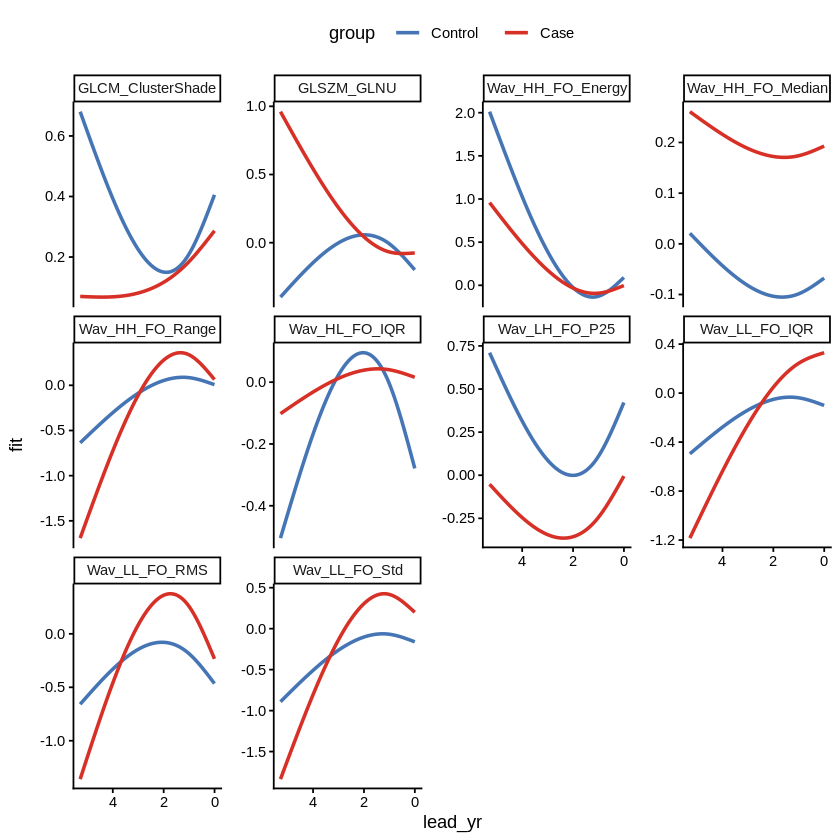

In [80]:
# ============================================================
# Lead-time longitudinal mixed model
#   - Uses raw timepoint-level data from Cell 2
#   - lead_time reconstructed from Days_Since_Surgery
# ============================================================

# ---------- package check ----------
pkgs <- c("lme4", "lmerTest", "ggplot2", "dplyr", "purrr", "merTools")
to_install <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
if (length(to_install) > 0) install.packages(to_install)

library(lme4)
library(lmerTest)
library(splines)   # base/recommended package, usually no install needed
library(ggplot2)
library(merTools)
library(dplyr)
library(purrr)

# ---------- df_long construction ----------
# IMPORTANT:
# - use raw (not df_tp) because this is a timepoint-level trajectory model
# - Days_To_T0 was removed in Cell 2, so reconstruct lead_time from Days_Since_Surgery

df_long <- raw %>%
  mutate(
    group = factor(ifelse(PI_MRONJ == 1, "Case", "Control"),
                   levels = c("Control", "Case")),
    lead_time = pmax(-Days_Since_Surgery, 0),   # days remaining to T0
    lead_yr   = lead_time / 365
  )

# Optional sanity check
cat("\n[df_long check]\n")
cat(sprintf("Rows: %d\n", nrow(df_long)))
cat(sprintf("Patients: %d\n", dplyr::n_distinct(df_long$Patient_ID)))
cat(sprintf("Implants: %d\n", dplyr::n_distinct(df_long$Implant_UID)))
cat(sprintf("Lead-time range (years): %.2f ~ %.2f\n",
            min(df_long$lead_yr, na.rm = TRUE),
            max(df_long$lead_yr, na.rm = TRUE)))

# ---------- features to test ----------
# NOTE:
# These are raw timepoint-level feature names (correct for df_long/raw)
champions <- c(
  "Wav_LL_FO_RMS",
  "Wav_HH_FO_Range",
  "Wav_HH_FO_Energy",
  "Wav_LL_FO_Std",
  "Wav_HL_FO_IQR",
  "GLSZM_GLNU",
  "GLCM_ClusterShade",
  "Wav_LH_FO_P25",
  "Wav_HH_FO_Median",
  "Wav_LL_FO_IQR"
)

# Check whether all feature columns exist
missing_feats <- setdiff(champions, names(df_long))
if (length(missing_feats) > 0) {
  stop("These features are missing in df_long/raw: ",
       paste(missing_feats, collapse = ", "))
}

# ---------- helper: robust model fit ----------
fit_div <- function(feat) {
  d <- df_long %>%
    select(Patient_ID, Implant_ID, Implant_UID, group, lead_yr, all_of(feat)) %>%
    rename(feature_value = all_of(feat)) %>%
    filter(!is.na(feature_value), !is.na(lead_yr), !is.na(group)) %>%
    mutate(y = as.numeric(scale(feature_value)))

  # feature variance check
  if (nrow(d) < 10 || sd(d$feature_value, na.rm = TRUE) == 0 || all(is.na(d$y))) {
    return(data.frame(
      Feature       = feat,
      Interaction_p = NA_real_,
      Group_p       = NA_real_,
      LeadTime_p    = NA_real_,
      N_timepoints  = nrow(d)
    ))
  }

  ct <- lmerControl(check.conv.singular = "ignore")

  # random effect:
  # using Implant_UID is safer because it is unique across whole dataset
  full <- tryCatch(
    lmer(y ~ group * ns(lead_yr, 2) + (1 | Patient_ID) + (1 | Implant_UID),
         data = d, REML = FALSE, control = ct),
    error = function(e) NULL
  )

  noInt <- tryCatch(
    lmer(y ~ group + ns(lead_yr, 2) + (1 | Patient_ID) + (1 | Implant_UID),
         data = d, REML = FALSE, control = ct),
    error = function(e) NULL
  )

  noGrp <- tryCatch(
    lmer(y ~ ns(lead_yr, 2) + (1 | Patient_ID) + (1 | Implant_UID),
         data = d, REML = FALSE, control = ct),
    error = function(e) NULL
  )

  noLT <- tryCatch(
    lmer(y ~ group + (1 | Patient_ID) + (1 | Implant_UID),
         data = d, REML = FALSE, control = ct),
    error = function(e) NULL
  )

  get_p <- function(m0, m1) {
    if (is.null(m0) || is.null(m1)) return(NA_real_)
    out <- tryCatch(anova(m0, m1), error = function(e) NULL)
    if (is.null(out) || !"Pr(>Chisq)" %in% names(out)) return(NA_real_)
    round(out$`Pr(>Chisq)`[2], 3)
  }

  data.frame(
    Feature       = feat,
    Interaction_p = get_p(noInt, full),   # divergence-onset
    Group_p       = get_p(noGrp, noInt),
    LeadTime_p    = get_p(noLT,  noInt),
    N_timepoints  = nrow(d)
  )
}

# ---------- run table ----------
div_table <- bind_rows(lapply(champions, fit_div))
print(div_table)

# ============================================================
# Visualization (facet by feature)
# ============================================================



grid_all_simple <- bind_rows(map(champions, function(feat) {

  d <- df_long %>%
    select(Patient_ID, Implant_UID, group, lead_yr, all_of(feat)) %>%
    rename(feature_value = all_of(feat)) %>%
    filter(!is.na(feature_value), !is.na(lead_yr), !is.na(group)) %>%
    mutate(y = as.numeric(scale(feature_value)))

  if (nrow(d) < 10 || sd(d$feature_value, na.rm = TRUE) == 0 || all(is.na(d$y))) {
    return(NULL)
  }

  m <- tryCatch(
    lmer(y ~ group * ns(lead_yr, 2) + (1 | Patient_ID) + (1 | Implant_UID),
         data = d, REML = FALSE,
         control = lmerControl(check.conv.singular = "ignore")),
    error = function(e) NULL
  )

  if (is.null(m)) return(NULL)

  grid <- expand.grid(
    lead_yr = seq(min(d$lead_yr, na.rm = TRUE),
                  max(d$lead_yr, na.rm = TRUE),
                  length.out = 60),
    group = factor(c("Control", "Case"), levels = c("Control", "Case"))
  )

  grid$fit <- predict(m, newdata = grid, re.form = NA)
  grid$Feature <- feat
  grid
}))

ggplot(grid_all_simple, aes(lead_yr, fit, color = group)) +
  geom_line(linewidth = 1) +
  scale_x_reverse() +
  facet_wrap(~ Feature, scales = "free_y") +
  scale_color_manual(values = c(Control = "#4575b4", Case = "#d73027")) +
  theme_classic(base_size = 11) +
  theme(legend.position = "top")


Basic analysis below

In [ ]:
# ==============================================================================
# [CELL 1] Descriptive statistics (Table 1) and patient/implant characteristic summary
# - Part 1: Characteristic sheet (patient-level N=7)
# - Part 2: Coding sheet (implant-level N=57, duplicate timepoints removed)
# ==============================================================================

# 1. load required packages
if(!require(tableone)) install.packages("tableone", quiet=TRUE)
if(!require(writexl)) install.packages("writexl", quiet=TRUE)
if(!require(dplyr)) install.packages("dplyr", quiet=TRUE)
if(!require(readxl)) install.packages("readxl", quiet=TRUE)

library(tableone)
library(writexl)
library(dplyr)
library(readxl)

cat("\n=======================================================\n")
cat("1. Loading Excel file (sheet-by-sheet)...\n")

# file path (edit for the local environment)
excel_file <- "/content/PI_MRONJ_v4.xlsx"

# load data per sheet
df_char_raw <- as.data.frame(read_excel(excel_file, sheet = "Characteristic"))
df_clinic_raw <- as.data.frame(read_excel(excel_file, sheet = "Coding"))

# unify the outcome variable name (defensive)
colnames(df_clinic_raw)[colnames(df_clinic_raw) == "PI-MRONJ"] <- "PI_MRONJ"
colnames(df_clinic_raw)[colnames(df_clinic_raw) == "PI.MRONJ"] <- "PI_MRONJ"


# ==============================================================================
# ★ [Part 1] build patient-characteristic summary table (N=7)
# ==============================================================================
cat("\n2. Building the patient-level summary table...\n")

# de-duplicate to patient level (defensive)
df_patient <- df_char_raw %>% distinct(Patient_ID, .keep_all = TRUE)
cat(sprintf("   - Filter result: extracted data for %d patients\n", nrow(df_patient)))

# coerce to numeric (error-guard: check the column exists)
if("Age" %in% colnames(df_patient)) {
  df_patient$Age <- as.numeric(as.character(df_patient$Age))
} else { cat("⚠️ Warning: no 'Age' column.\n") }

if("Admin_Duration_Months" %in% colnames(df_patient)) {
  df_patient$Admin_Duration_Months <- as.numeric(as.character(df_patient$Admin_Duration_Months))
} else { cat("⚠️ Warning: no 'Admin_Duration_Months' column.\n") }

# label categorical variables and build Table 1
if(all(c("DM", "HTN", "SEX") %in% colnames(df_patient))) {
  df_patient$DM <- factor(df_patient$DM, levels=c(0,1), labels=c("No", "Yes"))
  df_patient$HTN <- factor(df_patient$HTN, levels=c(0,1), labels=c("No", "Yes"))

  char_vars <- c("SEX", "Age", "DM", "HTN", "Admin_Duration_Months")
  char_cat <- c("SEX", "DM", "HTN")

  # overall statistics only, no group comparison (age: Mean/SD, drug duration: Median/IQR)
  tab_char <- CreateTableOne(vars = char_vars, data = df_patient, factorVars = char_cat)
  tab_char_print <- print(tab_char, showAllLevels = TRUE, nonnormal = c("Admin_Duration_Months"), quote=FALSE, noSpaces=TRUE)

  # save to Excel
  df_char_export <- as.data.frame(tab_char_print)
  df_char_export <- cbind(Variable = rownames(df_char_export), df_char_export)
  rownames(df_char_export) <- NULL
  write_xlsx(df_char_export, "./Patient_Demographics_Summary.xlsx")
  cat("✅ Patient summary table saved! (Patient_Demographics_Summary.xlsx)\n")
} else {
    cat("⚠️ Required patient variables missing; skipping table generation.\n")
}


# ==============================================================================
# ★ [Part 2] build implant clinical-feature statistical table (N=57)
# ==============================================================================
cat("\n3. Building the implant-level statistical test table (duplicate timepoints removed)...\n")

# create a unique implant identifier
if(!("Implant_UID" %in% colnames(df_clinic_raw))) {
  df_clinic_raw$Implant_UID <- paste(df_clinic_raw$Patient_ID, df_clinic_raw$Implant_ID, sep = "_")
}

# drop duplicate rows per implant UID (keep the baseline measurement only)
df_implant <- df_clinic_raw %>% distinct(Implant_UID, .keep_all = TRUE)
cat(sprintf("   - Filter result: extracted %d independent implants\n", nrow(df_implant)))

# data preprocessing
df_implant$Calculated_C_I_Ratio <- as.numeric(df_implant$Calculated_C_I_Ratio)
df_implant$Jaw_Code <- factor(df_implant$Jaw_Code, levels=c(1,2), labels=c("Maxilla", "Mandible"))
df_implant$Region_Code <- factor(df_implant$Region_Code, levels=c(1,2), labels=c("Anterior", "Posterior"))
df_implant$Is_Single_Prosthesis <- factor(df_implant$Is_Single_Prosthesis, levels=c(0,1), labels=c("Splinted", "Single"))
df_implant$Has_Cantilever <- factor(df_implant$Has_Cantilever, levels=c(0,1), labels=c("No", "Yes"))

# collapse opposing dentition into 2 groups
df_implant$Opposing_Binary <- ifelse(df_implant$Opposing_Teeth_Code == 2, "Opposing Implant", "Non-Implant")
df_implant$Opposing_Binary <- factor(df_implant$Opposing_Binary, levels=c("Non-Implant", "Opposing Implant"))

# specify analysis variables
clinic_cat <- c("Jaw_Code", "Region_Code", "Opposing_Binary", "Is_Single_Prosthesis", "Has_Cantilever")
clinic_cont <- c("Crown_Height_mm", "Calculated_C_I_Ratio",
                 "Insertion_Depth_mm", "Insertion_Angle_deviation")
clinic_all <- c(clinic_cat, clinic_cont)

# cross-tabulation and p-value computation
tab_clinic <- CreateTableOne(vars = clinic_all, strata = "PI_MRONJ", data = df_implant, factorVars = clinic_cat, addOverall = TRUE)
tab_clinic_print <- print(tab_clinic, nonnormal = clinic_cont, exact = clinic_cat, quote = FALSE, noSpaces = TRUE, showAllLevels = TRUE)

# save to Excel
df_clinic_export <- as.data.frame(tab_clinic_print)
df_clinic_export <- cbind(Variable = rownames(df_clinic_export), df_clinic_export)
rownames(df_clinic_export) <- NULL
write_xlsx(df_clinic_export, "./Table1_Clinical_Features_Stats.xlsx")

cat("✅ Implant statistical table saved! (Table1_Clinical_Features_Stats.xlsx)\n")
cat("=======================================================\n")


1. 엑셀 파일 불러오기 (시트별 분리 로딩)...

2. 환자 단위 단순 요약표를 생성합니다...
   - 필터링 결과: 총 7 명의 환자 데이터 추출 완료
                                      
                                       level Overall             
  n                                          7                   
  SEX (%)                              F     5 (71.4)            
                                       M     2 (28.6)            
  Age (mean (SD))                            78.86 (7.08)        
  DM (%)                               No    1 (14.3)            
                                       Yes   6 (85.7)            
  HTN (%)                              No    1 (14.3)            
                                       Yes   6 (85.7)            
  Admin_Duration_Months (median [IQR])       27.00 [13.50, 48.00]
✅ 환자 단순 요약표 저장 완료! (Patient_Demographics_Summary.xlsx)

3. 임플란트 단위 통계 검정표를 생성합니다 (중복 시점 제거)...
   - 필터링 결과: 총 58 건의 독립된 임플란트 추출 완료
                                          Stratified by PI_MRONJ
               

In [ ]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════╗
# ║   FIGURE 3 — Automated AUC Trend Plot (v4 Categorized Style) ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Font & package setup ──────────────────────────────────────
if(!require(showtext)) install.packages("showtext")
library(showtext)

# load the Arimo font under the name "Arial"
font_add_google(name = "Arimo", family = "Arial")
showtext_auto()
showtext_opts(dpi = 600) # for high-resolution output

suppressPackageStartupMessages({
  library(readxl)
  library(dplyr)
  library(purrr)
  library(ggplot2)
  library(patchwork)
  library(svglite)
})

# --- [prerequisite] specify the path where files are saved ---
SAVE_DIR <- "/content/Results_R"

# ── 1) Automated data extraction (reflects the v4 _Categorized structure) ──

# mapping of the newly split Excel files output by Cell 8
offsets_info <- list(
  list(file = "0M_Cell8_2Algo_Boot_Categorized.xlsx", offset = 0),
  list(file = "3M_Cell8_2Algo_Boot_Categorized.xlsx", offset = 3),
  list(file = "6M_Cell8_2Algo_Boot_Categorized.xlsx", offset = 6),
  list(file = "9M_Cell8_2Algo_Boot_Categorized.xlsx", offset = 9)
)

# internal model ID (Feature_Set) -> manuscript italic + subscript label (plotmath expression)
name_map_expr <- list(
  "CM_Depth"               = expression(bold(CM)[bold(Depth)]),
  "CRM_Depth_LHP25"        = expression(bold(CRM)[bold("Depth+LH-P25")]),
  "CRM_Depth_LHSkewTrend"  = expression(bold(CRM)[bold("Depth+\u0394LH-Skew")]),   # ★ ΔFO-IQR → ΔLH-Skew
  "RM_LHP25_LHSkewTrend"   = expression(bold(RM)[bold("LH-P25+\u0394LH-Skew")]),   # ★ ΔHH-Med → ΔLH-Skew
  "RM_LHP25_IQRtrend"      = expression(bold(RM)[bold("LH-P25+\u0394FO-IQR")]),
  "SRM_LHP25"              = expression(bold(SRM)[bold("LH-P25")])
)

# for color mapping / factor ordering — uses the internal ID as-is (only the label becomes an expression)
model_order <- c("CM_Depth", "CRM_Depth_LHP25", "CRM_Depth_LHSkewTrend",
                 "RM_LHP25_LHSkewTrend", "RM_LHP25_IQRtrend", "SRM_LHP25")

# function to extract data from Excel
extract_auc_trend <- function(info) {
  file_path <- file.path(SAVE_DIR, info$file)

  if (!file.exists(file_path)) {
    warning(sprintf("⚠️ File not found: %s", info$file))
    return(NULL)
  }

  # read the All_Results sheet
  df <- read_excel(file_path, sheet = "All_Results")

  df %>%
    filter(Feature_Set %in% model_order) %>%
    mutate(
      Model = factor(Feature_Set, levels = model_order),  # keep the internal ID as the factor
      Offset = info$offset,
      AUC = as.numeric(AUC_Adjusted)
    ) %>%
    select(Model, Algorithm, Offset, AUC)
}

# combine data across the 4 timepoints
fig3_data <- map_df(offsets_info, extract_auc_trend)

# ── 2) Visualization settings (color palette matching the DCA figure) ──
model_colors <- c(
  "CM_Depth"               = "#D62728", # red (CM)
  "CRM_Depth_LHP25"        = "#FF7F0E", # orange (CRM Static)
  "CRM_Depth_LHSkewTrend"  = "#A65628", # brown (CRM Dynamic)  ★ swapped
  "RM_LHP25_LHSkewTrend"   = "#984EA3", # purple (RM 1)         ★ swapped
  "RM_LHP25_IQRtrend"      = "#1F77B4", # blue (RM 2)
  "SRM_LHP25"              = "#4DAF4A"  # green (SRM)
)

# ── 3) Shared theme (inherits the Figure 4 manuscript style) ──
fig4_style <- theme_minimal() +
  theme(
    text             = element_text(family = "Arial"),
    plot.title       = element_text(size = 20, face = "bold",
                                    hjust = 0,
                                    margin = margin(b = 10)),
    axis.title.y = element_text(size = 14, face = "bold",
                                 margin = margin(r = 10)),
    axis.title.x = element_text(size = 14, face = "bold",
                                 margin = margin(t = 10)),
    axis.text        = element_text(size = 12, color = "black"),

    # grid guidelines
    panel.grid.major = element_line(color = "gray88", linewidth = 0.4),
    panel.grid.minor = element_blank(),

    # border and axis-line settings
    panel.border    = element_blank(),
    axis.line       = element_line(color = "black", linewidth = 0.5),

    # panel background
    plot.background  = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),

    plot.margin     = margin(t = 18, r = 10, b = 18, l = 10, unit = "pt"),

    # legend formatting
    legend.position  = "bottom",
    legend.title     = element_blank(),
    legend.text      = element_text(size = 12, face = "bold"),
    legend.key.width = unit(1.6, "cm"),
    legend.spacing.x = unit(0.5, "cm"),
    legend.margin    = margin(t = 10, b = 5)
  )

# ── 4) Generate per-algorithm panels ─────────────────────────────────────

# LR Panel (revised)
p_lr <- ggplot(filter(fig3_data, Algorithm == "LR"),
               aes(x = Offset, y = AUC, color = Model, group = Model)) +
  geom_line(linewidth = 0.9) +
  geom_point(shape = 16, size = 2.5) +
  scale_color_manual(values = model_colors, labels = name_map_expr) +
  scale_x_reverse(breaks = c(9, 6, 3, 0), labels = c("9M", "6M", "3M", "0M")) +
  scale_y_continuous(
    limits = c(0.45, 0.85),
    breaks = seq(0.45, 0.85, 0.10)   # ★ 0.45, 0.55, 0.65, 0.75, 0.85
  ) +
  labs(title = "(A) Logistic Regression",
       x = "Offset (Months Before Surgery)",
       y = "Optimism-corrected AUC") +
  fig4_style

# XGB Panel (revised)
p_xgb <- ggplot(filter(fig3_data, Algorithm == "XGB"),
                aes(x = Offset, y = AUC, color = Model, group = Model)) +
  geom_line(linewidth = 0.9) +
  geom_point(shape = 16, size = 2.5) +
  scale_color_manual(values = model_colors, labels = name_map_expr) +
  scale_x_reverse(breaks = c(9, 6, 3, 0), labels = c("9M", "6M", "3M", "0M")) +
  scale_y_continuous(
    limits = c(0.70, 0.90),
    breaks = seq(0.70, 0.90, 0.05)   # ★ 0.75, 0.80, 0.85, 0.90, 0.95
  ) +
  labs(title = "(B) XGBoost",
       x = "Offset (Months Before Surgery)",
       y = "Optimism-corrected AUC") +
  fig4_style

# ── 5) Combine panels and build high-resolution output ───────────────────

fig3_final <- p_lr + p_xgb +
  plot_layout(guides = "collect") &
  theme(legend.position = "bottom") &
  guides(color = guide_legend(
    nrow = 2, byrow = TRUE,
    override.aes = list(linewidth = 1.2, size = 3)
  ))

# High-quality image spec (600 DPI, lossless LZW-compressed output)
ggsave("Figure3_AUC_Trend_Final.tiff", fig3_final, width=12, height=6, dpi=600, compression="lzw")
ggsave("Figure3_AUC_Trend_Final.pdf", fig3_final, width=12, height=6)
ggsave("Figure3_AUC_Trend_Final.svg", fig3_final, width=12, height=6, device = svglite::svglite)

cat("\n✅ [Success] Figure 3 saved, fully synced with the updated Excel results (TIFF, PDF, SVG).")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE 4 — 2×2 + bottom legend    ║
# ║  - Input: v4 _Categorized.xlsx (Cell 9 output)               ║
# ║  - Filtering: extracts only the Top 6 models (12 lines) for plotting ║
# ║  - Legend: bottom-left aligned (Left=LR, Right=XGB)          ║
# ║  - XGB marker: plain "*" (avoids a TIFF encoding error)      ║
# ╚══════════════════════════════════════════════════════════════╝

suppressPackageStartupMessages({
  library(dcurves)
  library(ggplot2)
  library(readxl)
  library(cowplot)
})

# load required packages
if(!require(showtext)) install.packages("showtext")
library(showtext)

# make R recognize Arial among the system fonts
font_add_google(name = "Arimo", family = "Arial")
showtext_auto()
showtext_opts(dpi = 600)

# --- [prerequisite] specify the path where files are saved ---
SAVE_DIR <- "/content/Results_R"

# ── 1) Labels — bold + subscript expression list ─────────────
# two per model (LR / XGB*) — using plotmath expressions
ace_model_labels <- list(
  "CM_Depth_LR"               = expression(bold(CM)[bold(Depth)] * " (LR)"),
  "CM_Depth_XGB"              = expression(bold(CM)[bold(Depth)] * " (XGB)"^"*"),

  "CRM_Depth_LHP25_LR"        = expression(bold(CRM)[bold("Depth+LH-P25")] * " (LR)"),
  "CRM_Depth_LHP25_XGB"       = expression(bold(CRM)[bold("Depth+LH-P25")] * " (XGB)"^"*"),

  "CRM_Depth_LHSkewTrend_LR"  = expression(bold(CRM)[bold("Depth+\u0394LH-Skew")] * " (LR)"),
  "CRM_Depth_LHSkewTrend_XGB" = expression(bold(CRM)[bold("Depth+\u0394LH-Skew")] * " (XGB)"^"*"),

  "RM_LHP25_LHSkewTrend_LR"   = expression(bold(RM)[bold("LH-P25+\u0394LH-Skew")] * " (LR)"),
  "RM_LHP25_LHSkewTrend_XGB"  = expression(bold(RM)[bold("LH-P25+\u0394LH-Skew")] * " (XGB)"^"*"),

  "RM_LHP25_IQRtrend_LR"      = expression(bold(RM)[bold("LH-P25+\u0394FO-IQR")] * " (LR)"),
  "RM_LHP25_IQRtrend_XGB"     = expression(bold(RM)[bold("LH-P25+\u0394FO-IQR")] * " (XGB)"^"*"),

  "SRM_LHP25_LR"              = expression(bold(SRM)[bold("LH-P25")] * " (LR)"),
  "SRM_LHP25_XGB"             = expression(bold(SRM)[bold("LH-P25")] * " (XGB)"^"*")
)

# ── 2) Colors (keeps the original golden-ratio palette) ─────────
dca_colors <- c(
  "Treat All"                 = "darkgray", "Treat None"                = "black",
  "CM_Depth_LR"               = "#D62728",  "CM_Depth_XGB"              = "#D62728",  # red
  "CRM_Depth_LHP25_LR"        = "#FF7F0E",  "CRM_Depth_LHP25_XGB"       = "#FF7F0E",  # orange
  "CRM_Depth_LHSkewTrend_LR"  = "#A65628",  "CRM_Depth_LHSkewTrend_XGB" = "#A65628",  # brown ★
  "RM_LHP25_LHSkewTrend_LR"   = "#984EA3",  "RM_LHP25_LHSkewTrend_XGB"  = "#984EA3",  # purple ★
  "RM_LHP25_IQRtrend_LR"      = "#1F77B4",  "RM_LHP25_IQRtrend_XGB"     = "#1F77B4",  # blue
  "SRM_LHP25_LR"              = "#4DAF4A",  "SRM_LHP25_XGB"             = "#4DAF4A"   # green
)

# ── 3) Linetypes (XGB uses "22" dashed, LR uses "solid") ────────
dca_linetypes <- c(
  "Treat All"                 = "solid",    "Treat None"                = "solid",
  "CM_Depth_LR"               = "solid",    "CM_Depth_XGB"              = "22",
  "CRM_Depth_LHP25_LR"        = "solid",    "CRM_Depth_LHP25_XGB"       = "22",
  "CRM_Depth_LHSkewTrend_LR"  = "solid",    "CRM_Depth_LHSkewTrend_XGB" = "22",
  "RM_LHP25_LHSkewTrend_LR"   = "solid",    "RM_LHP25_LHSkewTrend_XGB"  = "22",
  "RM_LHP25_IQRtrend_LR"      = "solid",    "RM_LHP25_IQRtrend_XGB"     = "22",
  "SRM_LHP25_LR"              = "solid",    "SRM_LHP25_XGB"             = "22"
)

# Treat All / Treat None stay as plain strings; model labels are expressions
legend_labels <- c(
  list("Treat All" = "Treat All", "Treat None" = "Treat None"),
  ace_model_labels
)
legend_breaks <- names(dca_colors)

# ── 4) Panel function (applies the logic that extracts Top 6 of 60) ──
make_native_dca <- function(file_path, panel_title) {

  if (!file.exists(file_path)) {
    warning(sprintf("⚠️ File not found: %s", file_path))
    return(NULL)
  }

  # load the sheet with predicted probabilities for all 60 models
  df_prob <- read_excel(file_path, sheet = "Probabilities")

  # 🚨 [key fix] extract only the Event column and the ace_models columns (avoids spaghetti plots)
  target_cols <- c("Event", names(ace_model_labels))
  df_prob <- df_prob[, target_cols]

  # build the formula
  models  <- names(ace_model_labels)
  dca_formula <- as.formula(paste("Event ~", paste(models, collapse = " + ")))
  dca_res <- dcurves::dca(dca_formula, data = df_prob)

  p <- plot(dca_res, smooth = TRUE) +
    aes(linetype = label) +
    scale_color_manual(values = dca_colors, labels = legend_labels, breaks = legend_breaks) +
    scale_linetype_manual(values = dca_linetypes, labels = legend_labels, breaks = legend_breaks) +
    scale_x_continuous(breaks = seq(0, 0.75, by = 0.1), expand = c(0, 0)) +
    coord_cartesian(xlim = c(0, 0.75), ylim = c(-0.1, 0.35)) +
    labs(title = panel_title, x = "Risk Threshold", y = "Net Benefit") +
    theme_minimal() +
    theme(
    text = element_text(family = "Arial"),
    plot.title  = element_text(size = 18, face = "bold", hjust = 0, margin = margin(b = 10)),
    axis.title  = element_text(size = 14, face = "bold"),
    axis.text   = element_text(size = 12, color = "black"),                    # ★ added
    panel.grid.major = element_line(color = "gray88", linewidth = 0.4),       # (optional) matches Figure 3
    panel.grid.minor = element_blank(),                                        # (optional) matches Figure 3
    legend.position = "none",
    plot.background  = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    plot.margin = margin(t = 18, r = 8, b = 18, l = 8, unit = "pt")
  )

}

# ── 5) Render 4 panels (reflects the revised Categorized filenames) ──
offsets <- list(
  list(file = "0M_Cell9_ClinicalDefense_Categorized.xlsx", title = "(A) 0-month offset from surgery"),
  list(file = "3M_Cell9_ClinicalDefense_Categorized.xlsx", title = "(B) 3-month offset from surgery"),
  list(file = "6M_Cell9_ClinicalDefense_Categorized.xlsx", title = "(C) 6-month offset from surgery"),
  list(file = "9M_Cell9_ClinicalDefense_Categorized.xlsx", title = "(D) 9-month offset from surgery")
)

panels <- lapply(offsets, function(o) make_native_dca(file.path(SAVE_DIR, o$file), o$title))

# ── 6) left aligned, 2 columns grouped ─
lr_keys  <- grep("_LR$",  legend_breaks, value = TRUE)
xgb_keys <- grep("_XGB$", legend_breaks, value = TRUE)

legend_breaks_d <- c("Treat All", lr_keys, "Treat None", xgb_keys)
legend_breaks_d <- legend_breaks_d[legend_breaks_d %in% legend_breaks]
legend_labels_d <- legend_labels[legend_breaks_d]

legend_dummy <- data.frame(
  x = rep(c(1, 2), times = length(legend_breaks_d)),
  y = rep(c(1, 2), times = length(legend_breaks_d)),
  model = factor(rep(legend_breaks_d, each = 2), levels = legend_breaks_d)
)

p_legend <- ggplot(legend_dummy, aes(x = x, y = y, color = model, linetype = model, group = model)) +
  geom_line(linewidth = 1.1) +
  scale_color_manual(values = dca_colors,   breaks = legend_breaks_d, labels = legend_labels_d) +
  scale_linetype_manual(values = dca_linetypes, breaks = legend_breaks_d, labels = legend_labels_d) +
  theme_void() +
  theme(
  text = element_text(family = "Arial"),
  legend.position = "bottom",
  legend.justification = "left",
  legend.box.just = "left",
  legend.title = element_blank(),
  legend.text  = element_text(size = 13, face = "bold", margin = margin(r = 22)),  # ★ 13pt
  legend.box.margin = margin(t = -4, r = 0, b = -4, l = 4, unit = "pt"),
  legend.key.width = unit(1.8, "cm"),
  legend.spacing.y = unit(0.15, "cm")
) +
  guides(
    color    = guide_legend(ncol = 2, byrow = FALSE),
    linetype = guide_legend(ncol = 2, byrow = FALSE)
  )

shared_legend <- get_legend(p_legend)

# ── 7) Assemble: 2×2 panels + bottom-left legend ───────────────
row_plots <- plot_grid(
  panels[[1]], panels[[2]],
  panels[[3]], panels[[4]],
  ncol = 2, align = "hv"
)

row_legend <- plot_grid(shared_legend, ncol = 1, align = "h")

fig4_final <- plot_grid(
  row_plots,
  row_legend,
  ncol = 1,
  rel_heights = c(1, 0.30)
)

# ── 8) Export ───────────────────────────────────
tiff_path <- file.path(SAVE_DIR, "Figure4_DCA_Final.tiff")
pdf_path  <- file.path(SAVE_DIR, "Figure4_DCA_Final.pdf")
svg_path  <- file.path(SAVE_DIR, "Figure4_DCA_Final.svg")

FIG_W <- 12
FIG_H <- 15

if (requireNamespace("ragg", quietly = TRUE)) {
  ggsave(tiff_path, fig4_final, width = FIG_W, height = FIG_H, units = "in",
         dpi = 600, compression = "lzw", bg = "white",
         device = ragg::agg_tiff)
} else {
  ggsave(tiff_path, fig4_final, width = FIG_W, height = FIG_H, units = "in",
         dpi = 600, compression = "lzw", bg = "white")
}

ggsave(pdf_path, fig4_final, width = FIG_W, height = FIG_H, units = "in", bg = "white")
ggsave(svg_path, fig4_final, width = FIG_W, height = FIG_H, units = "in", device = svglite::svglite, bg = "white")

cat(sprintf("\n✅ Figure 4 (DCA 2x2 Panels) successfully saved:\n 📍 TIFF: %s\n 📍 PDF: %s\n 📍 SVG: %s\n", tiff_path, pdf_path, svg_path))

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  FIGURE S2 — Offset Stability Heatmap (v4 Categorized Sync)  ║
# ╚══════════════════════════════════════════════════════════════╝

suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(patchwork)
  library(svglite)
  library(showtext)
  library(readxl)
})

SAVE_DIR <- "/content/Results_R"

# ── 1. Font & resolution setup ────────────────────────────────────
font_add_google(name = "Arimo", family = "Arial")
showtext_auto()
showtext_opts(dpi = 600) # keeps font size in sync at high resolution

# ── 2. Data setup (reflects the v4 lineup and latest _Categorized files) ──────
model_order <- c(
  "CM_Depth",
  "CRM_Depth+LH-P25",
  "CRM_Depth+\u0394LH-Skew",
  "RM_LH-P25+\u0394LH-Skew",
  "RM_LH-P25+\u0394FO-IQR",
  "SRM_LH-P25"
)

# apply plotmath syntax: italic(Base[Subscript])
model_labels_formatted <- c(
  "CM_Depth"                = expression(italic(CM[Depth])),
  "CRM_Depth+LH-P25"        = expression(italic(CRM[Depth*"+"*LH-P25])),
  "CRM_Depth+\u0394LH-Skew" = expression(italic(CRM[Depth*"+"*Delta*LH-Skew])),
  "RM_LH-P25+\u0394LH-Skew" = expression(italic(RM[LH-P25*"+"*Delta*LH-Skew])),
  "RM_LH-P25+\u0394FO-IQR"  = expression(italic(RM[LH-P25*"+"*Delta*FO-IQR])),
  "SRM_LH-P25"              = expression(italic(SRM[LH-P25]))
)

# 🚨 [revised] added the Categorized Excel filenames (synced to Cell 8 v4 output)
offsets_info <- list(
  list(file = "0M_Cell8_2Algo_Boot_Categorized.xlsx", offset_label = "0M"),
  list(file = "3M_Cell8_2Algo_Boot_Categorized.xlsx", offset_label = "3M"),
  list(file = "6M_Cell8_2Algo_Boot_Categorized.xlsx", offset_label = "6M"),
  list(file = "9M_Cell8_2Algo_Boot_Categorized.xlsx", offset_label = "9M")
)

# internal ID (the Excel Feature_Set column) -> display name mapping for the plot
name_map <- c(
  "CM_Depth"              = "CM_Depth",
  "CRM_Depth_LHP25"       = "CRM_Depth+LH-P25",
  "CRM_Depth_LHSkewTrend" = "CRM_Depth+\u0394LH-Skew",   # ★ ΔFO-IQR → ΔLH-Skew
  "RM_LHP25_LHSkewTrend"  = "RM_LH-P25+\u0394LH-Skew",   # ★ ΔHH-Med → ΔLH-Skew
  "RM_LHP25_IQRtrend"     = "RM_LH-P25+\u0394FO-IQR",
  "SRM_LHP25"             = "SRM_LH-P25"
)

# extract both AUC_Adjusted and Optimism from each Excel file
extract_heatmap_data <- function(info) {
  file_path <- file.path(SAVE_DIR, info$file)

  if (!file.exists(file_path)) {
    warning(sprintf("⚠️ File not found: %s", info$file))
    return(NULL)
  }

  df <- read_excel(file_path, sheet = "All_Results")

  df %>%
    filter(Feature_Set %in% names(name_map)) %>%
    mutate(
      Model = factor(name_map[Feature_Set], levels = model_order),
      Offset = info$offset_label,
      AUC = as.numeric(AUC_Adjusted),
      Opt = as.numeric(Optimism),
      Algorithm = factor(Algorithm, levels = c("LR", "XGB"))
    ) %>%
    select(Model, Algorithm, Offset, AUC, Opt)
}

# combine the 4 files
auc_data_all <- map_df(offsets_info, extract_heatmap_data)

# preprocess data for the heatmap
offsets_order <- c("9M", "6M", "3M", "0M")

df_heat <- auc_data_all %>%
  mutate(
    Model     = factor(Model, levels = rev(model_order)), # reversed so rows print top-to-bottom in order
    Offset    = factor(Offset, levels = offsets_order),
    Algorithm = factor(Algorithm, levels = c("LR","XGB")),
    # when Opt > 0.10, apply an overfitting dagger (†) superscript and bold formatting
    Label     = ifelse(Opt > 0.10, sprintf("bold('%.3f')^'\u2020'", AUC), sprintf("bold('%.3f')", AUC)),
    # auto-invert text color by AUC value (for contrast against the background)
    TextColor = ifelse(AUC >= 0.850 | AUC <= 0.550, "white", "black")
  )

# ── 3. Plot function (adjusts legend text position and x-axis title) ─────────
make_heatmap <- function(data, algo_label, show_y = TRUE, show_legend = FALSE) {
  p <- ggplot(data, aes(x = Offset, y = Model, fill = AUC)) +
    geom_tile(color = "white", linewidth = 0.8) +
    geom_text(aes(label = Label, color = TextColor), size = 4, family = "Arial", parse = TRUE) +
    scale_fill_gradientn(
      colours = c("#4575b4", "#74add1", "#abd9e9", "#e0f3f8", "#fee090", "#fdae61", "#f46d43", "#d73027"),
      limits  = c(0.45, 0.90),
      name    = "AUC\n(Opt-corrected)",
      guide   = guide_colorbar(barwidth = 1.0, barheight = 10, title.position = "top", title.hjust = 0.5)
    ) +
    scale_color_identity() +
    scale_y_discrete(labels = model_labels_formatted) +
    scale_x_discrete(labels = offsets_order) +
    labs(title = algo_label, x = "Offset (Months Before Surgery)", y = NULL) +
    coord_fixed(ratio = 1) +
    theme_minimal(base_family = "Arial") +
    theme(
      plot.title       = element_text(size=16, face="bold", hjust=0.5, margin=margin(b=10)),
      axis.text.x      = element_text(size=12, color="black", face="bold"),
      axis.text.y      = if(show_y) element_text(size=12, color="black", hjust=1) else element_blank(),
      axis.title.x     = element_text(size=11, face="bold", margin=margin(t=10)),
      panel.grid       = element_blank(),
      legend.position  = if(show_legend) "right" else "none",
      legend.title     = element_text(size=12, face="bold"),
      legend.text      = element_text(size=11, vjust = 1.5),
      plot.margin      = margin(10, 5, 10, 5, "pt"),
      plot.background  = element_rect(fill="white", color=NA),
      panel.background = element_rect(fill="white", color=NA)
    )
  return(p)
}

# ── 4. Generate and combine panels ─────────────────────────────────
p_lr  <- make_heatmap(filter(df_heat, Algorithm == "LR"),  "(A) Logistic Regression", show_y = TRUE,  show_legend = FALSE)
p_xgb <- make_heatmap(filter(df_heat, Algorithm == "XGB"), "(B) XGBoost",             show_y = FALSE, show_legend = TRUE)

figS2_final <- p_lr + p_xgb + plot_layout(guides = "collect")

# ── 5. Save (matrix enlarged by adjusting the canvas size) ────────────
FIG_W <- 12
FIG_H <- 8

ggsave(file.path(SAVE_DIR, "FigureS2_Heatmap_Final.tiff"), figS2_final, width=FIG_W, height=FIG_H, units="in", dpi=600, compression="lzw", bg="white")
ggsave(file.path(SAVE_DIR, "FigureS2_Heatmap_Final.pdf"),  figS2_final, width=FIG_W, height=FIG_H, units="in", bg="white")
ggsave(file.path(SAVE_DIR, "FigureS2_Heatmap_Final.svg"),  figS2_final, width=FIG_W, height=FIG_H, units="in", device=svglite::svglite, bg="white")

cat("✅ Figure S2: synced with Categorized files and plotted (TIFF, PDF, SVG)\n")

✅ Figure S2: Categorized 파일 연동 및 플로팅 완료 (TIFF, PDF, SVG)


In [ ]:
# ==============================================================================
# PI-MRONJ Radiomics ICC(2,1) Analysis Pipeline (Ultimate Failsafe Version)
# Two-way random effects, absolute agreement, single measurement + 95% CI
# ==============================================================================

# 1. load packages (tidyr issue resolved)
if(!require(readxl)) install.packages("readxl")
if(!require(dplyr)) install.packages("dplyr")
if(!require(irr)) install.packages("irr")
if(!require(stringr)) install.packages("stringr")

library(readxl)
library(dplyr)
library(irr)
library(stringr)

# 2. load data
master <- read_excel("Radiomics_v37_Final_Results.xlsx")
intra  <- read_excel("Radiomics_v37_Final_Results_Intra_obs.xlsx")
inter  <- read_excel("Radiomics_v37_Final_Results_Inter_obs.xlsx")

# 3. define robust, never-failing normalization helpers
force_clean_id <- function(x) {
  toupper(str_replace_all(as.character(x), "[^a-zA-Z0-9]", ""))
}

force_clean_date <- function(x) {
  str_replace_all(as.character(x), "[^0-9]", "")
}

# 4. build UID (Patient + Implant + Date)
master <- master %>% mutate(UID = paste(force_clean_id(Patient_ID), force_clean_id(Implant_ID), force_clean_date(Study_Date), sep="_"))
intra  <- intra  %>% mutate(UID = paste(force_clean_id(Patient_ID), force_clean_id(Implant_ID), force_clean_date(Study_Date), sep="_"))
inter  <- inter  %>% mutate(UID = paste(force_clean_id(Patient_ID), force_clean_id(Implant_ID), force_clean_date(Study_Date), sep="_"))

# 5. inspect UIDs before matching (debug output)
cat("--- UID matching debug ---\n")
cat("Master UID Sample: ", head(master$UID, 3), "\n")
cat("Intra  UID Sample: ", head(intra$UID, 3), "\n")
cat("Inter  UID Sample: ", head(inter$UID, 3), "\n")

# 6. extract common features
exclude_cols <- c("Patient_ID", "Implant_ID", "Study_Date", "PI-MRONJ",
                  "T0_Surgery", "Days_Since_Surgery", "Valid_Pixels", "UID")
features <- setdiff(intersect(colnames(master), colnames(intra)), exclude_cols)

cat(sprintf("\n▶ Radiomic features to analyze: %d\n", length(features)))

# 7. merge (inner join)
df_intra_merged <- inner_join(master, intra, by = "UID", suffix = c("_orig", "_repeat"))
df_inter_merged <- inner_join(master, inter, by = "UID", suffix = c("_orig", "_repeat"))

cat(sprintf("▶ Intra-observer matched rows: %d\n", nrow(df_intra_merged)))
cat(sprintf("▶ Inter-observer matched rows: %d\n", nrow(df_inter_merged)))

# 8. compute ICC and extract 95% CI
if(nrow(df_intra_merged) == 0 | nrow(df_inter_merged) == 0) {
  stop("🚨 0 matched rows. Re-check the UID construction.")
}

# 💡 function fix: use base na.omit() instead of drop_na()
calc_icc_detailed <- function(df, feature_name) {
  col_orig <- paste0(feature_name, "_orig")
  col_rep  <- paste0(feature_name, "_repeat")

  # remove rows containing missing values
  sub_df <- df %>% select(all_of(col_orig), all_of(col_rep)) %>% na.omit()

  if (nrow(sub_df) < 5) {
    return(data.frame(ICC = NA, CI_lo = NA, CI_hi = NA))
  }

  res <- icc(sub_df, model = "twoway", type = "agreement", unit = "single")

  return(data.frame(
    ICC = res$value,
    CI_lo = res$lbound,
    CI_hi = res$ubound
  ))
}

# collect results as a list via lapply, then combine with bind_rows
# intra-observer
intra_results <- lapply(features, function(f) {
  res <- calc_icc_detailed(df_intra_merged, f)
  res$Feature <- f
  res <- res %>% rename(ICC_Intra = ICC, CI_lo_Intra = CI_lo, CI_hi_Intra = CI_hi)
  return(res)
}) %>% bind_rows()

# inter-observer
inter_results <- lapply(features, function(f) {
  res <- calc_icc_detailed(df_inter_merged, f)
  res$Feature <- f
  res <- res %>% rename(ICC_Inter = ICC, CI_lo_Inter = CI_lo, CI_hi_Inter = CI_hi)
  return(res)
}) %>% bind_rows()

# merge intra and inter results
icc_results <- full_join(intra_results, inter_results, by = "Feature")

# 9. round decimals and add a manuscript-ready string column
icc_results <- icc_results %>%
  select(Feature, ICC_Intra, CI_lo_Intra, CI_hi_Intra, ICC_Inter, CI_lo_Inter, CI_hi_Inter) %>%
  mutate(across(where(is.numeric), ~round(., 3))) %>%
  # create an 'ICC (lower - upper)' string column for direct pasting into the manuscript
  mutate(
    Intra_95CI_String = ifelse(is.na(ICC_Intra), NA, paste0(ICC_Intra, " (", CI_lo_Intra, "-", CI_hi_Intra, ")")),
    Inter_95CI_String = ifelse(is.na(ICC_Inter), NA, paste0(ICC_Inter, " (", CI_lo_Inter, "-", CI_hi_Inter, ")"))
  )

# filtering logic (operates on numeric ICC_Intra, ICC_Inter columns)
stable_features <- icc_results %>% filter(ICC_Intra >= 0.75 & ICC_Inter >= 0.75)
excellent_features <- icc_results %>% filter(ICC_Intra >= 0.90 & ICC_Inter >= 0.90)

# print and save results
cat("\n=== Final ICC summary (Intra / Inter) ===\n")
print(summary(icc_results[, c("ICC_Intra", "ICC_Inter")]))

# use fileEncoding = "UTF-8" to keep text encoding intact
write.csv(icc_results, "ICC_all_features_with_CI.csv", row.names = FALSE, fileEncoding = "UTF-8")
write.csv(stable_features, "ICC_stable_features_with_CI.csv", row.names = FALSE, fileEncoding = "UTF-8")

cat("\n✅ Analysis complete. CSV with 95% CI saved successfully.\n")

--- UID 매칭 디버깅 ---
Master UID Sample:  PT01_46I_20170508 PT01_47I_20170508 PT01_46I_20190529 
Intra  UID Sample:  PT01_46I_20170508 PT01_47I_20170508 PT02_12I_20250218 
Inter  UID Sample:  PT05_11I_20200519 PT05_12I_20200519 PT05_16I_20200519 

▶ 분석 대상 라디오믹스 피처 수: 125 개
▶ 관찰자 내(Intra) 매칭 데이터: 34 행
▶ 관찰자 간(Inter) 매칭 데이터: 31 행

=== 최종 ICC 통계 요약 (Intra / Inter) ===
   ICC_Intra         ICC_Inter     
 Min.   :-0.4950   Min.   :0.0040  
 1st Qu.: 0.9080   1st Qu.:0.5630  
 Median : 0.9570   Median :0.7920  
 Mean   : 0.9008   Mean   :0.7152  
 3rd Qu.: 0.9750   3rd Qu.:0.8910  
 Max.   : 0.9910   Max.   :0.9920  

✅ 분석 완료. 95% CI가 포함된 CSV 저장 성공.


In [ ]:
# ==============================================================================
# PI-MRONJ Clinical Feature ICC(2,1) Analysis (Simplified for 2 Datasets)
# Two-way random effects, absolute agreement, single measurement
# ==============================================================================

# 1. install and load packages (Colab environment)
if(!require(dplyr))   install.packages("dplyr")
if(!require(irr))     install.packages("irr")
if(!require(writexl)) install.packages("writexl")
if(!require(readxl))  install.packages("readxl")

library(dplyr)
library(irr)
library(writexl)
library(readxl)

# ==============================================================================
# 2. load data
# uncomment the block matching the extension of your uploaded file.
# ==============================================================================
# if the file is CSV:
#d1 <- read.csv("#1.xlsx - #1 icc.csv", stringsAsFactors = FALSE) # Master
#d2 <- read.csv("#2.xlsx - #2 icc.csv", stringsAsFactors = FALSE) # 2nd Observer

# if the file is Excel (.xlsx) (comment out the CSV lines above and use these):
d1 <- read_excel("#1.xlsx")
d2 <- read_excel("#2.xlsx")

# ==============================================================================
# 3. define clinical variables to analyze (per the uploaded data's column names)
# ==============================================================================
clin_vars <- c(
  "Insertion_Depth_mm",    # or "Calculated_insertion_depth"
  "Insertion_Angle_deg",
  "Crown_Height_mm",
  "Calculated_C_I_Ratio"
)

# ==============================================================================
# 4. build UID from Patient_ID + Implant_ID and match
# ==============================================================================
make_uid <- function(df) {
  df %>%
    mutate(UID = paste(
      toupper(gsub("[^a-zA-Z0-9]", "", as.character(Patient_ID))),
      toupper(gsub("[^a-zA-Z0-9]", "", as.character(Implant_ID))),
      sep = "_"
    )) %>%
    group_by(UID) %>%
    slice(1) %>% # keep only the first row per implant
    ungroup()
}

d1_uid <- make_uid(d1)
d2_uid <- make_uid(d2)

cat("=== Data size ===\n")
cat(sprintf("Dataset 1: %d implants\n", nrow(d1_uid)))
cat(sprintf("Dataset 2: %d implants\n", nrow(d2_uid)))

# inner-join the two datasets on UID
df_matched <- inner_join(
  d1_uid %>% select(UID, any_of(clin_vars)),
  d2_uid %>% select(UID, any_of(clin_vars)),
  by = "UID", suffix = c("_1", "_2")
)

cat(sprintf("\n=== Matching result ===\n"))
cat(sprintf("Total matched implants: %d pairs\n", nrow(df_matched)))

if(nrow(df_matched) == 0) {
  stop("No matched data. Check the UID construction or the Patient/Implant ID format.")
}

# ==============================================================================
# 5. define the ICC(2,1) computation function
# ==============================================================================
calc_icc <- function(df, var) {
  col_1 <- paste0(var, "_1")
  col_2 <- paste0(var, "_2")

  # check the variable exists in both datasets
  if (!col_1 %in% names(df) | !col_2 %in% names(df)) {
    return(c(ICC=NA, CI_lo=NA, CI_hi=NA, N=0))
  }

  # keep only rows without missing values
  sub <- df %>% select(all_of(c(col_1, col_2))) %>% drop_na()

  if (nrow(sub) < 3) {
    return(c(ICC=NA, CI_lo=NA, CI_hi=NA, N=nrow(sub)))
  }

  # Two-way random, Absolute agreement, Single measurement
  res <- icc(sub, model="twoway", type="agreement", unit="single")

  c(ICC   = round(res$value, 3),
    CI_lo = round(res$lbound, 3),
    CI_hi = round(res$ubound, 3),
    N     = nrow(sub))
}

# ==============================================================================
# 6. aggregate and evaluate results
# ==============================================================================
icc_table <- data.frame(Variable = clin_vars, stringsAsFactors = FALSE)

for (v in clin_vars) {
  res <- calc_icc(df_matched, v)

  icc_table$ICC[icc_table$Variable == v]   <- res["ICC"]
  icc_table$`95% CI`[icc_table$Variable == v] <- sprintf("%.3f – %.3f", res["CI_lo"], res["CI_hi"])
  icc_table$N[icc_table$Variable == v]     <- res["N"]
}

# assign reliability grades per Koo & Li (2016)
grade <- function(icc) {
  ifelse(is.na(icc), "—",
  ifelse(icc >= 0.90, "Excellent",
  ifelse(icc >= 0.75, "Good",
  ifelse(icc >= 0.50, "Moderate", "Poor"))))
}

icc_table$Grade <- grade(icc_table$ICC)

# ==============================================================================
# 7. print results
# ==============================================================================
cat("\n=== Clinical Feature ICC(2,1) Results ===\n")
cat(sprintf("%-30s %6s %-18s %-12s %s\n", "Variable", "N", "ICC", "95% CI", "Grade"))
cat(strrep("-", 80), "\n")
for (i in seq_len(nrow(icc_table))) {
  r <- icc_table[i, ]
  cat(sprintf("%-30s %6d %6.3f   %-16s %s\n",
              r$Variable, r$N, r$ICC, r$`95% CI`, r$Grade))
}

# ==============================================================================
# 8. save to Excel
# ==============================================================================
write_xlsx(icc_table, "Final_ICC_Results.xlsx")
cat("\n✅ Analysis complete and saved: Final_ICC_Results.xlsx\n")

=== 데이터 크기 ===
Dataset 1: 31 임플란트
Dataset 2: 31 임플란트

=== 매칭 결과 ===
총 매칭된 임플란트: 31 쌍

=== Clinical Feature ICC(2,1) Results ===
Variable                            N ICC                95% CI       Grade
-------------------------------------------------------------------------------- 
Insertion_Depth_mm                 31  0.794   0.595 – 0.898  Good
Insertion_Angle_deg                28  0.708   0.461 – 0.853  Moderate
Crown_Height_mm                    28  0.962   0.921 – 0.982  Excellent
Calculated_C_I_Ratio               28  0.966   0.929 – 0.984  Excellent

✅ 분석 완료 및 저장됨: Final_ICC_Results.xlsx
